In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import seaborn as sns

# from posydon.popsyn.binarypopulation import BinaryPopulation
# from posydon.binary_evol.binarystar import BinaryStar
# from posydon.binary_evol.singlestar import SingleStar
from posydon.popsyn.synthetic_population import Population
# from posydon.popsyn.synthetic_population import PopulationRunner
# import astropy.units as u
# 
# import os
# import shutil
# from posydon.config import PATH_TO_POSYDON

from POSYDONHRDiagramModule import HR_Diagram

import matplotlib.pyplot as plt
import matplotlib as mpl

import random as rand 

from collections import Counter


DataPath = Path().resolve().parent / 'Data'

In [2]:
mpl.rcParams.update({
    "pgf.texsystem": "pdflatex",  
    "font.family": "serif",       
    "text.usetex": True,          
    "pgf.rcfonts": False,         
})

In [3]:
cols = ['time', 'step_names', 'state', 'event', 'S1_state', 'S2_state', 'S1_mass', 'S2_mass', 'orbital_period']
finCols = [
    'orbital_period_f',
    'eccentricity_f',
    'state_f',

    'S1_state_f',
    'S2_state_f',
    
    'S2_mass_f',
    'S2_log_R_f',
    'S2_log_L_f',


    'S1_mass_f',
    'S1_log_R_f',
    'S1_log_L_f'

 ]

initCols = [
    'orbital_period_i',
    'eccentricity_i',
    'state_i',

    'S2_state_i',
    'S2_mass_i',
    'S2_log_R_i',

    'S1_state_i',
    'S1_mass_i',
    'S1_log_R_i'
 ]

In [4]:
def basicColHist(df, var: str, 
                 title: str | None = None, 
                 xLabel: str | None = None, 
                 saveFig: bool = False, 
                 savePath: Path = Path(),
                 df_name: str = 'default'
                 ) -> None:
    fig, ax = plt.subplots(figsize=(8,5))
    
    sns.histplot(df[var], bins=50, ax=ax)
    
    if title is None:
        title = f'{var} of BH-Sol systems at S1 SN'
    if xLabel is None:
        xLabel = var

    ax.set_title(title)
    ax.set_xlabel(xLabel)
    ax.set_ylabel('Count')

    if saveFig:
        clean_name = title.replace(' ', '_').replace('/', '-') + '.pgf'
        plt.savefig(savePath / clean_name, bbox_inches='tight')

    plt.show()

def genVarHist(var: list, title: str | None = None, xLabel: str | None = None, saveFig: bool = False, savePath: Path = Path()) -> None:
    fig, ax = plt.subplots(figsize=(8,5))
    
    sns.histplot(var, bins=50, ax=ax)
    
    if title is None:
        title = 'default'
    if xLabel is None:
        xLabel = 'default'

    ax.set_title(title)
    ax.set_xlabel(xLabel)
    ax.set_ylabel('Count')

    if saveFig:
        clean_name = title.replace(' ', '_').replace('/', '-') + '.pgf'
        plt.savefig(savePath / clean_name, bbox_inches='tight')

    plt.show()

In [5]:
def xVsY(
    xvar: str|list, yvar: str|list,
    df: pd.DataFrame | None = None,
    useDF: bool = True, 
    title: str | None = None,
    xLabel: str | None = None,
    yLabel: str | None = None,
    saveFig: bool = False,
    savePath: Path = Path(),
    fit: bool = False,
    ci: int = 95,
    df_name: str = 'default'

) -> None:
    fig, ax = plt.subplots(figsize=(8, 5))

    if useDF:
        x = df[xvar] if isinstance(xvar, str) else xvar
        y = df[yvar] if isinstance(yvar, str) else yvar
    else:
        x, y = xvar, yvar  
        
    if fit:
        sns.regplot(x=x, y=y, ci=ci, ax=ax,
                    line_kws={"color": "red", "linestyle": "--", "linewidth": 2},
                    scatter_kws={"alpha": 0.6})
    else:
        sns.scatterplot(x=x, y=y, alpha=0.6, ax=ax)

    if title is None:
        if isinstance(xvar, str) and isinstance(yvar, str):
            title = f'{xvar} vs {yvar} of BH-Sol systems at S1 SN'
        else:
            title = 'Variable Comparison'

    if xLabel is None:
        xLabel = xvar if isinstance(xvar, str) else 'X-Axis'
        
    if yLabel is None:
        yLabel = yvar if isinstance(yvar, str) else 'Y-Axis'

    ax.set_title(title)
    ax.set_xlabel(xLabel)
    ax.set_ylabel(yLabel)

    if saveFig:
        clean_name = title.replace(' ', '_').replace('/', '-') + '.pgf'
        plt.savefig(savePath / clean_name, bbox_inches='tight')

    plt.show()

In [6]:
### sunlike
pop = Population(str(DataPath / 'SunLikeStar_Filt' / 'BH_Sol_Filtered_1e+00_Zsun_population.h5'))
bhSolRows = pd.read_csv(DataPath /'SunLikeStar_Filt' / 'BH_Sol_Filtered_1e+00_Zsun_population.csv')
bhSolRows_Aftr = pd.read_csv(DataPath /'SunLikeStar_Filt' / 'BH_Sol_Filtered_1e+00_Zsun_populationAftRow.csv')
bhSolRows_Prev = pd.read_csv(DataPath /'SunLikeStar_Filt' / 'BH_Sol_Filtered_1e+00_Zsun_populationprevRow.csv')

bhSolRows = bhSolRows.drop(17, axis='index')
bhSolRows_Aftr = bhSolRows_Aftr.drop(17, axis='index')
bhSolRows_Prev = bhSolRows_Prev.drop(17, axis='index')


pOneline = pop.oneline.select()
pHistory = pop.history.select()

pOneline = pOneline.drop(17, axis='index')
pHistory = pHistory.drop(17, axis='index')

pop.ini_params

{'metallicity': 1.0,
 'number_of_binaries': 1000000,
 'binary_fraction_scheme': 'const',
 'binary_fraction_const': 1.0,
 'star_formation': 'constant',
 'max_simulation_time': 13800000000.0,
 'primary_mass_scheme': 'Kroupa2001',
 'primary_mass_min': 12,
 'primary_mass_max': 100,
 'secondary_mass_scheme': 'Moe+17-PsandQs',
 'secondary_mass_min': 0.1,
 'secondary_mass_max': 10,
 'orbital_scheme': 'period',
 'orbital_period_scheme': 'Moe+17-PsandQs',
 'orbital_period_min': 5,
 'orbital_period_max': 8000,
 'orbital_separation_scheme': 'log_uniform',
 'orbital_separation_min': 5.0,
 'orbital_separation_max': 100000.0,
 'eccentricity_scheme': 'Moe+17-PsandQs',
 'posydon_version': '0+unknown'}

In [7]:
# ### 10MilPop
# df_name = '10Mill'
# pop = Population(str(DataPath / '10MillFilt' / 'BH_Sol_Filtered_1e+00_Zsun_population.h5'))
# bhSolRows = pd.read_csv(DataPath /'10MillFilt' / 'BH_Sol_Filtered_1e+00_Zsun_population.csv')
# bhSolRows_Aftr = pd.read_csv(DataPath /'10MillFilt' / 'BH_Sol_Filtered_1e+00_Zsun_populationAftRow.csv')
# bhSolRows_Prev = pd.read_csv(DataPath /'10MillFilt' / 'BH_Sol_Filtered_1e+00_Zsun_populationprevRow.csv')

# bhSolRows['deltaM1SN'] = (bhSolRows_Prev['S1_mass'] - bhSolRows['S1_mass'])
# dropIs = bhSolRows['deltaM1SN'].nsmallest(2).index.to_list() # <- these are two systems where its RLO onto a NS which then collapses into a BH, but they both error out and arent really what we're looking for? so easier to drop


# bhSolRows = bhSolRows.drop(dropIs, axis='index')
# bhSolRows_Aftr = bhSolRows_Aftr.drop(dropIs, axis='index')
# bhSolRows_Prev = bhSolRows_Prev.drop(dropIs, axis='index')


# pOneline = pop.oneline.select()
# pHistory = pop.history.select()

# pOneline = pOneline.drop(dropIs, axis='index')
# pHistory = pHistory.drop(dropIs, axis='index')

# pop.ini_params



In [8]:
####1d-02Zsun
pop_02Z = Population(str(DataPath / '1e-02Zsun' / 'BH_Sol_Filtered_1e-02_Zsun_population.h5'))
bhSolRows_02Z = pd.read_csv(DataPath /'1e-02Zsun' / 'BH_Sol_Filtered_1e-02_Zsun_population.csv')

bhSolRows_Aftr_02Z = pd.read_csv(DataPath /'1e-02Zsun' / 'BH_Sol_Filtered_1e-02_Zsun_populationAftRow.csv')
bhSolRows_Prev_02Z = pd.read_csv(DataPath /'1e-02Zsun' / 'BH_Sol_Filtered_1e-02_Zsun_populationprevRow.csv')


pOneline_02Z = pop.oneline.select()
pHistory_02Z = pop.history.select()

fc = pop_02Z.formation_channels
mask = fc['channel'] == 'ZAMS_oCE1_CC1_oRLO2_CC2_maxtime_END'
binary_indices_02Z = fc[mask].index.tolist()

pOneline_02Z = pop_02Z.oneline[binary_indices_02Z]
pHistory_02Z = pop_02Z.history[binary_indices_02Z]

bhSolRows_02Z = bhSolRows_02Z.loc[binary_indices_02Z]

pop_02Z.ini_params


{'metallicity': 0.01,
 'number_of_binaries': 1000000,
 'binary_fraction_scheme': 'const',
 'binary_fraction_const': 1.0,
 'star_formation': 'constant',
 'max_simulation_time': 13800000000.0,
 'primary_mass_scheme': 'Kroupa2001',
 'primary_mass_min': 12,
 'primary_mass_max': 100,
 'secondary_mass_scheme': 'Moe+17-PsandQs',
 'secondary_mass_min': 0.1,
 'secondary_mass_max': 10,
 'orbital_scheme': 'period',
 'orbital_period_scheme': 'Moe+17-PsandQs',
 'orbital_period_min': 5,
 'orbital_period_max': 8000,
 'orbital_separation_scheme': 'log_uniform',
 'orbital_separation_min': 5.0,
 'orbital_separation_max': 100000.0,
 'eccentricity_scheme': 'zero',
 'posydon_version': '0+unknown'}

In [9]:
### merged pop

pop_merged = Population(str(DataPath / 'failedSystems.h5'))

pOneline_merged = pop_merged.oneline.select()

pHistory_merged = pop_merged.history.select()

In [10]:
pOneline[initCols].describe()

,orbital_period_i,eccentricity_i,S2_mass_i,S2_log_R_i,S1_mass_i,S1_log_R_i
count,45.000000,45.000000,45.000000,45.0,45.000000,45.0
mean,4150.149389,0.532376,2.195909,0.0,16.826121,0.0
std,158.999350,0.207057,0.348479,0.0,1.107231,0.0
min,3844.570082,0.075718,1.551266,0.0,14.878710,0.0
25%,4016.808617,0.456794,1.880662,0.0,16.077692,0.0
50%,4170.976368,0.534800,2.188940,0.0,16.665842,0.0
75%,4273.375834,0.688032,2.474821,0.0,17.672163,0.0
max,4390.052803,0.825958,2.753904,0.0,19.435080,0.0


In [11]:
pOneline_merged

,state_i,event_i,time_i,orbital_period_i,eccentricity_i,lg_mtransfer_rate_i,step_names_i,step_times_i,S1_state_i,S1_mass_i,...,interp_class_CO_HMS_RLO,interp_class_CO_HeMS,interp_class_CO_HeMS_RLO,mt_history_HMS_HMS,mt_history_CO_HMS_RLO,mt_history_CO_HeMS,mt_history_CO_HeMS_RLO,FAILED,WARNING,metallicity
binary_index,,,,,,,,,,,,,,,,,,,,,
0,detached,ZAMS,7.782037e+09,3957.766065,0.906189,NaN,initial_cond,0.0,H-rich_Core_H_burning,16.275477,...,NaN,NaN,NaN,Unstable RLOF during postMS,NaN,NaN,NaN,0,1,1.0
1,detached,ZAMS,1.331356e+10,4315.464597,0.626028,NaN,initial_cond,0.0,H-rich_Core_H_burning,18.193304,...,NaN,NaN,NaN,Unstable RLOF during postMS,NaN,NaN,NaN,0,1,1.0
2,detached,ZAMS,1.191930e+09,4094.415836,0.826915,NaN,initial_cond,0.0,H-rich_Core_H_burning,19.547507,...,NaN,NaN,NaN,Unstable RLOF during postMS,NaN,NaN,NaN,0,1,1.0
3,detached,ZAMS,1.740057e+09,4321.346381,0.676240,NaN,initial_cond,0.0,H-rich_Core_H_burning,17.393802,...,NaN,NaN,NaN,Unstable RLOF during postMS,NaN,NaN,NaN,0,1,1.0
4,detached,ZAMS,1.299998e+10,3915.048011,0.853262,NaN,initial_cond,0.0,H-rich_Core_H_burning,18.345373,...,NaN,NaN,NaN,Unstable RLOF during postMS,NaN,NaN,NaN,0,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233,detached,ZAMS,8.365818e+09,3956.430109,0.963147,NaN,initial_cond,0.0,H-rich_Core_H_burning,16.863457,...,NaN,NaN,NaN,Unstable RLOF during postMS,NaN,NaN,NaN,0,1,1.0
234,detached,ZAMS,2.084565e+09,4019.145979,0.905204,NaN,initial_cond,0.0,H-rich_Core_H_burning,18.497876,...,NaN,NaN,NaN,Unstable RLOF during postMS,NaN,NaN,NaN,0,1,1.0
235,detached,ZAMS,5.851540e+09,4041.362731,0.698113,NaN,initial_cond,0.0,H-rich_Core_H_burning,16.353732,...,NaN,NaN,NaN,Unstable RLOF during postMS,NaN,NaN,NaN,0,1,1.0


In [12]:
pOneline_02Z

,state_i,event_i,time_i,orbital_period_i,eccentricity_i,lg_mtransfer_rate_i,step_names_i,step_times_i,S1_state_i,S1_mass_i,...,interp_class_CO_HMS_RLO,interp_class_CO_HeMS,interp_class_CO_HeMS_RLO,mt_history_HMS_HMS,mt_history_CO_HMS_RLO,mt_history_CO_HeMS,mt_history_CO_HeMS_RLO,FAILED,WARNING,metallicity
binary_index,,,,,,,,,,,,,,,,,,,,,
0,detached,ZAMS,4.035779e+09,2601.184779,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,18.182762,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,0.01
2,detached,ZAMS,3.076035e+09,3136.277507,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,17.256266,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,0.01
3,detached,ZAMS,3.911211e+09,3002.832222,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,17.103747,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,0.01
4,detached,ZAMS,7.092487e+09,2864.788796,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,15.841658,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,0.01
5,detached,ZAMS,8.921784e+09,3010.813232,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,17.526981,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,0.01
6,detached,ZAMS,3.719153e+08,2922.317516,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,15.028368,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,0.01
7,detached,ZAMS,8.156287e+09,3012.777478,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,16.202626,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,0.01
8,detached,ZAMS,7.275431e+08,2972.226028,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,15.916362,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,0.01
11,detached,ZAMS,3.326343e+09,3056.267366,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,15.492378,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,0.01


In [13]:
pOneline_02Z

,state_i,event_i,time_i,orbital_period_i,eccentricity_i,lg_mtransfer_rate_i,step_names_i,step_times_i,S1_state_i,S1_mass_i,...,interp_class_CO_HMS_RLO,interp_class_CO_HeMS,interp_class_CO_HeMS_RLO,mt_history_HMS_HMS,mt_history_CO_HMS_RLO,mt_history_CO_HeMS,mt_history_CO_HeMS_RLO,FAILED,WARNING,metallicity
binary_index,,,,,,,,,,,,,,,,,,,,,
0,detached,ZAMS,4.035779e+09,2601.184779,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,18.182762,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,0.01
2,detached,ZAMS,3.076035e+09,3136.277507,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,17.256266,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,0.01
3,detached,ZAMS,3.911211e+09,3002.832222,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,17.103747,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,0.01
4,detached,ZAMS,7.092487e+09,2864.788796,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,15.841658,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,0.01
5,detached,ZAMS,8.921784e+09,3010.813232,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,17.526981,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,0.01
6,detached,ZAMS,3.719153e+08,2922.317516,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,15.028368,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,0.01
7,detached,ZAMS,8.156287e+09,3012.777478,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,16.202626,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,0.01
8,detached,ZAMS,7.275431e+08,2972.226028,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,15.916362,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,0.01
11,detached,ZAMS,3.326343e+09,3056.267366,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,15.492378,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,0.01


In [14]:
pOneline

,state_i,event_i,time_i,orbital_period_i,eccentricity_i,lg_mtransfer_rate_i,step_names_i,step_times_i,S1_state_i,S1_mass_i,...,interp_class_CO_HMS_RLO,interp_class_CO_HeMS,interp_class_CO_HeMS_RLO,mt_history_HMS_HMS,mt_history_CO_HMS_RLO,mt_history_CO_HeMS,mt_history_CO_HeMS_RLO,FAILED,WARNING,metallicity
binary_index,,,,,,,,,,,,,,,,,,,,,
0,detached,ZAMS,4.487391e+09,4028.254542,0.357737,NaN,initial_cond,0.0,H-rich_Core_H_burning,18.338584,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,1.0
1,detached,ZAMS,8.370801e+09,3905.179808,0.084004,NaN,initial_cond,0.0,H-rich_Core_H_burning,19.435080,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,1.0
2,detached,ZAMS,9.537004e+09,4137.423411,0.757557,NaN,initial_cond,0.0,H-rich_Core_H_burning,17.983938,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,1.0
3,detached,ZAMS,2.010199e+09,4370.857404,0.754004,NaN,initial_cond,0.0,H-rich_Core_H_burning,15.506937,...,NaN,NaN,NaN,Unstable RLOF during postMS,NaN,NaN,NaN,0,1,1.0
4,detached,ZAMS,8.812934e+09,3844.570082,0.455501,NaN,initial_cond,0.0,H-rich_Core_H_burning,18.146652,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,1.0
5,detached,ZAMS,9.918955e+09,4271.287670,0.824328,NaN,initial_cond,0.0,H-rich_Core_H_burning,15.696276,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,1.0
6,detached,ZAMS,9.210831e+09,4291.679268,0.458543,NaN,initial_cond,0.0,H-rich_Core_H_burning,15.546078,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,1.0
7,detached,ZAMS,2.996557e+08,4035.130603,0.664716,NaN,initial_cond,0.0,H-rich_Core_H_burning,16.311274,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,1.0
8,detached,ZAMS,8.242985e+09,3965.440144,0.659758,NaN,initial_cond,0.0,H-rich_Core_H_burning,16.906712,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,1.0


In [15]:
bhSolRows[cols]

,time,step_names,state,event,S1_state,S2_state,S1_mass,S2_mass,orbital_period
0,4.498900e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,2.679673,2.998272,1.494220
1,8.381730e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,4.517730,2.945927,1.884652
2,9.548856e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,3.141908,2.671987,2.740360
3,2.025330e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,2.667703,1.613518,0.796016
4,8.824689e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,3.118031,2.971203,3.317456
5,9.934345e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,3.746899,2.079317,6.844816
6,9.226441e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,3.621245,1.854338,7.859836
7,3.143854e+08,step_SN,detached,NaN,BH,H-rich_Core_H_burning,4.164533,2.635615,52.749603
8,8.256869e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,4.515033,2.891355,15.899186
9,7.629761e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,3.932408,2.700722,14.974814


In [16]:
bhSolRows_Prev[cols]

,time,step_names,state,event,S1_state,S2_state,S1_mass,S2_mass,orbital_period
0,4.498900e+09,step_detached,detached,CC1,stripped_He_Core_He_depleted,H-rich_Core_H_burning,6.724137,2.998272,1.658225
1,8.381730e+09,step_detached,detached,CC1,stripped_He_Core_He_depleted,H-rich_Core_H_burning,8.055778,2.945927,1.341035
2,9.548856e+09,step_detached,detached,CC1,stripped_He_Core_He_depleted,H-rich_Core_H_burning,7.175882,2.671987,1.233283
3,2.025330e+09,step_detached,detached,CC1,stripped_He_Core_C_depleted,H-rich_Core_H_burning,6.709519,1.613518,1.020614
4,8.824689e+09,step_detached,detached,CC1,stripped_He_Core_He_depleted,H-rich_Core_H_burning,7.169269,2.971203,2.344240
5,9.934345e+09,step_detached,detached,CC1,stripped_He_Core_He_depleted,H-rich_Core_H_burning,7.396295,2.079317,11.366438
6,9.226441e+09,step_detached,detached,CC1,stripped_He_Core_C_depleted,H-rich_Core_H_burning,7.321082,1.854338,11.848820
7,3.143854e+08,step_detached,detached,CC1,stripped_He_Core_He_depleted,H-rich_Core_H_burning,7.796588,2.635615,64.995027
8,8.256869e+09,step_detached,detached,CC1,stripped_He_Core_He_depleted,H-rich_Core_H_burning,8.051447,2.891355,22.432903
9,7.629761e+09,step_detached,detached,CC1,stripped_He_Core_He_depleted,H-rich_Core_H_burning,7.580045,2.700722,9.074883


In [17]:
bhSolRows_Aftr

,binary_index,state,event,time,orbital_period,eccentricity,lg_mtransfer_rate,step_names,step_times,S1_state,...,S2_he_core_mass,S2_he_core_radius,S2_co_core_mass,S2_co_core_radius,S2_center_h1,S2_center_he4,S2_surface_h1,S2_surface_he4,S2_surf_avg_omega_div_omega_crit,S2_spin
0,22892,RLO2,oRLO2,4.733361e+09,1.178322,0.000000,NaN,step_detached,0.224224,BH,...,0.000000,NaN,0.0,0.0,3.039558e-01,0.682172,0.715500,0.270271,0.305947,7.659746
1,30640,RLO2,oRLO2,8.678259e+09,1.647085,0.000000,NaN,step_detached,0.185177,BH,...,0.000000,NaN,0.0,0.0,1.707228e-01,0.815410,0.715500,0.270271,0.272739,6.643741
2,98004,RLO2,oRLO2,9.931025e+09,1.533841,0.000000,NaN,step_detached,0.225967,BH,...,0.000000,NaN,0.0,0.0,1.743975e-01,0.811734,0.715500,0.270271,0.270678,6.589525
3,152104,initial_RLOF,NaN,2.025330e+09,0.796016,0.669528,NaN,step_detached,0.122659,BH,...,0.000000,NaN,0.0,0.0,7.053057e-01,0.280090,0.715500,0.270271,0.032131,0.904615
4,197243,RLO2,oRLO2,8.998543e+09,0.888638,0.000000,NaN,step_detached,0.162106,BH,...,0.000000,NaN,0.0,0.0,4.547238e-01,0.531379,0.715500,0.270271,0.295724,7.751433
5,214571,RLO2,oRLO2,1.056800e+10,1.051319,0.000000,NaN,step_detached,0.192319,BH,...,0.000000,NaN,0.0,0.0,3.052691e-01,0.680842,0.715500,0.270271,0.304389,7.564082
6,217672,RLO2,oRLO2,1.043827e+10,2.059796,0.000000,NaN,step_detached,0.268717,BH,...,0.157216,NaN,0.0,0.0,4.103004e-09,0.986134,0.715500,0.270271,0.269319,5.780493
7,227670,RLO2,oRLO2,7.764266e+08,10.563417,0.000000,NaN,step_detached,0.333869,BH,...,0.310419,NaN,0.0,0.0,0.000000e+00,0.986138,0.714853,0.270684,0.251985,48.539670
8,234637,RLO2,oRLO2,8.614523e+09,3.696162,0.000000,NaN,step_detached,0.287439,BH,...,0.286815,NaN,0.0,0.0,7.996492e-17,0.986139,0.715500,0.270271,0.154092,3.403077
9,271714,RLO2,oRLO2,8.060640e+09,11.375472,0.000000,NaN,step_detached,0.485476,BH,...,0.319085,NaN,0.0,0.0,0.000000e+00,0.986139,0.714904,0.270645,0.295954,57.827706


In [18]:
####1d-01Zsun
# pop = Population(str(DataPath / '1e-01Zsun' / 'BH_Sol_Filtered_1e-01_Zsun_population.h5'))
# bhSolRows = pd.read_csv(DataPath /'1e-01Zsun' / 'BH_Sol_Filtered_1e-01_Zsun_population.csv')

In [19]:
pop.calculate_formation_channels()

Formation channels already exist in the parsed population file!
Channels will be overwriten


In [20]:
Counter(pop.formation_channels['channel'])

Counter({'ZAMS_oCE1_CC1_oRLO2_CC2_maxtime_END': 35,
         'ZAMS_oCE1_CC1_oRLO2_maxtime_END': 7,
         'ZAMS_oCE1_CC1_END': 3,
         'ZAMS_oRLO1_CC1_oRLO2_CC2_FAILED': 1})

In [21]:
bhSolRows

,binary_index,state,event,time,orbital_period,eccentricity,lg_mtransfer_rate,step_names,step_times,S1_state,...,S2_he_core_mass,S2_he_core_radius,S2_co_core_mass,S2_co_core_radius,S2_center_h1,S2_center_he4,S2_surface_h1,S2_surface_he4,S2_surf_avg_omega_div_omega_crit,S2_spin
0,22892,detached,NaN,4.498900e+09,1.494220,0.360938,NaN,step_SN,0.002222,BH,...,0.0,NaN,0.0,0.0,0.691616,0.294023,0.7155,0.270271,0.105856,3.023514
1,30640,detached,NaN,8.381730e+09,1.884652,0.142856,NaN,step_SN,0.004856,BH,...,0.0,NaN,0.0,0.0,0.696244,0.289355,0.7155,0.270271,0.125305,3.578513
2,98004,detached,NaN,9.548856e+09,2.740360,0.351989,NaN,step_SN,0.003183,BH,...,0.0,NaN,0.0,0.0,0.695545,0.290039,0.7155,0.270271,0.097579,2.769272
3,152104,detached,NaN,2.025330e+09,0.796016,0.669528,NaN,step_SN,0.001699,BH,...,0.0,NaN,0.0,0.0,0.705203,0.280193,0.7155,0.270271,0.032131,0.904615
4,197243,detached,NaN,8.824689e+09,3.317456,0.600119,NaN,step_SN,0.002589,BH,...,0.0,NaN,0.0,0.0,0.695127,0.290483,0.7155,0.270271,0.080369,2.296414
5,214571,detached,NaN,9.934345e+09,6.844816,0.716792,NaN,step_SN,0.003830,BH,...,0.0,NaN,0.0,0.0,0.701769,0.283705,0.7155,0.270271,0.033424,0.937796
6,217672,detached,NaN,9.226441e+09,7.859836,0.598014,NaN,step_SN,0.003460,BH,...,0.0,NaN,0.0,0.0,0.704175,0.281255,0.7155,0.270271,0.030181,0.845591
7,227670,detached,NaN,3.143854e+08,52.749603,0.663875,NaN,step_SN,0.004207,BH,...,0.0,NaN,0.0,0.0,0.698373,0.287186,0.7155,0.270271,0.039821,1.129760
8,234637,detached,NaN,8.256869e+09,15.899186,0.622247,NaN,step_SN,0.004924,BH,...,0.0,NaN,0.0,0.0,0.696121,0.289475,0.7155,0.270271,0.050934,1.452895
9,271714,detached,NaN,7.629761e+09,14.974814,0.357936,NaN,step_SN,0.003989,BH,...,0.0,NaN,0.0,0.0,0.696206,0.289376,0.7155,0.270271,0.048040,1.364186


In [22]:
pOneline[pOneline['S2_mass_i'] > 3]

,state_i,event_i,time_i,orbital_period_i,eccentricity_i,lg_mtransfer_rate_i,step_names_i,step_times_i,S1_state_i,S1_mass_i,...,interp_class_CO_HMS_RLO,interp_class_CO_HeMS,interp_class_CO_HeMS_RLO,mt_history_HMS_HMS,mt_history_CO_HMS_RLO,mt_history_CO_HeMS,mt_history_CO_HeMS_RLO,FAILED,WARNING,metallicity
binary_index,,,,,,,,,,,,,,,,,,,,,


In [23]:
# print(((pOneline['orbital_period_i'].describe()).to_frame().style.format().to_latex(column_format='|l|r|')).replace('_', '\_').replace('%', '\%'))

In [24]:
# print(((pOneline['S2_mass_i'].describe()).to_frame().style.format().to_latex(column_format='|l|r|')).replace('_', '\_').replace('%', '\%'))

In [25]:
# print(((pOneline['S1_mass_i'].describe()).to_frame().style.format().to_latex(column_format='|l|r|')).replace('_', '\_').replace('%', '\%'))

In [26]:
pOneline['eccentricity_f'].describe()

count    45.000000
mean      0.044134
std       0.167015
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max       0.669528
Name: eccentricity_f, dtype: float64

In [27]:
graphSave = Path.cwd().parent / 'Reports' /'4_10_26' / 'graphs'

In [28]:
# basicColHist(pOneline, 'eccentricity_i')

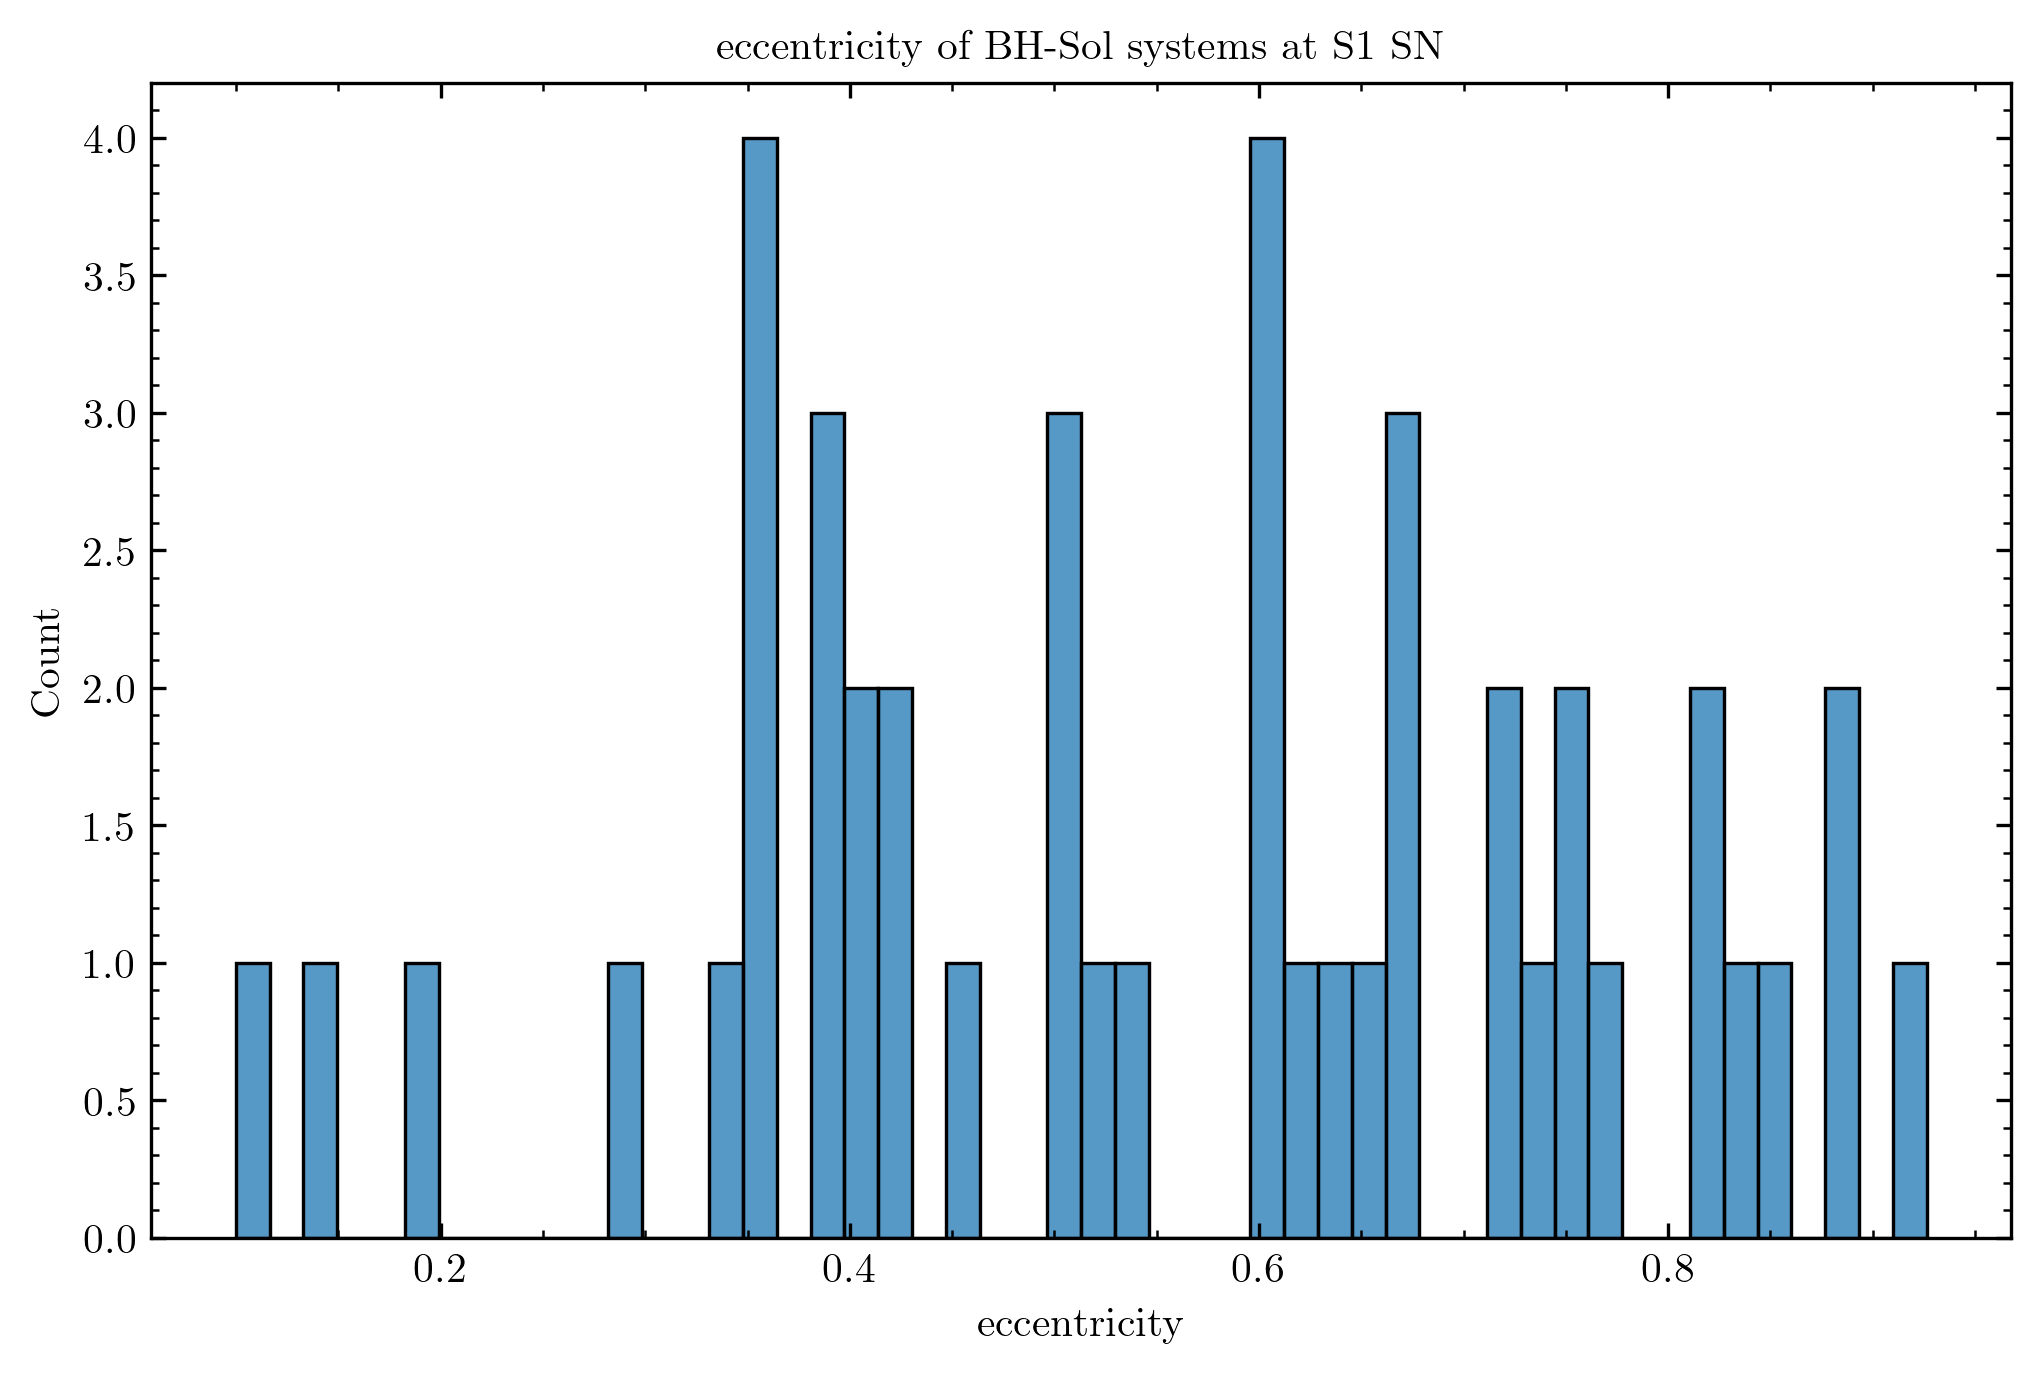

In [29]:
basicColHist(bhSolRows, 'eccentricity')

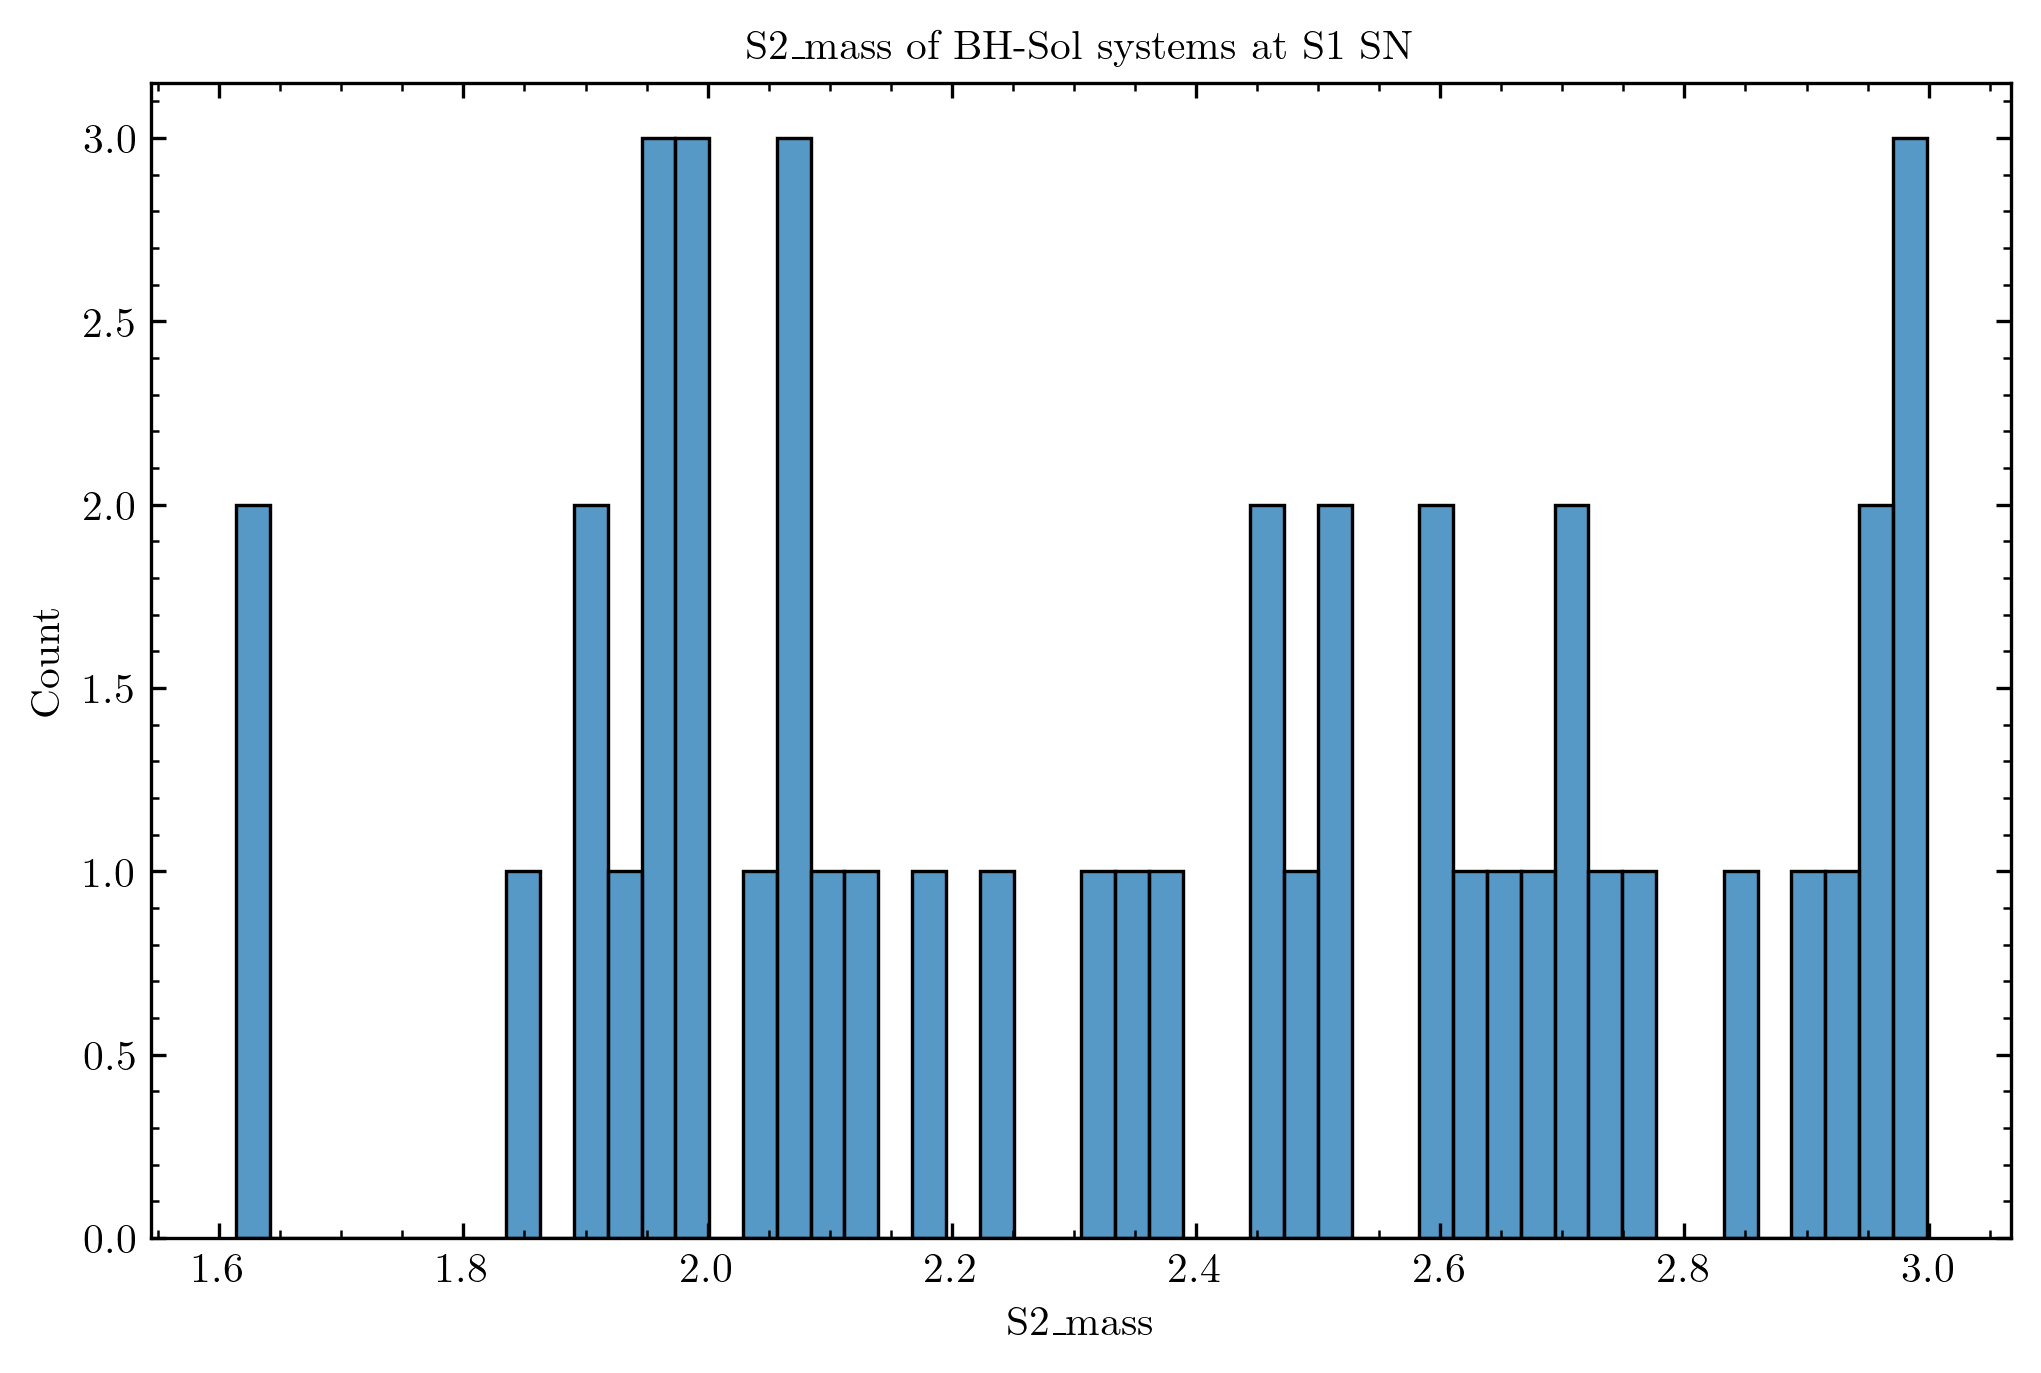

In [30]:
basicColHist(bhSolRows,'S2_mass')

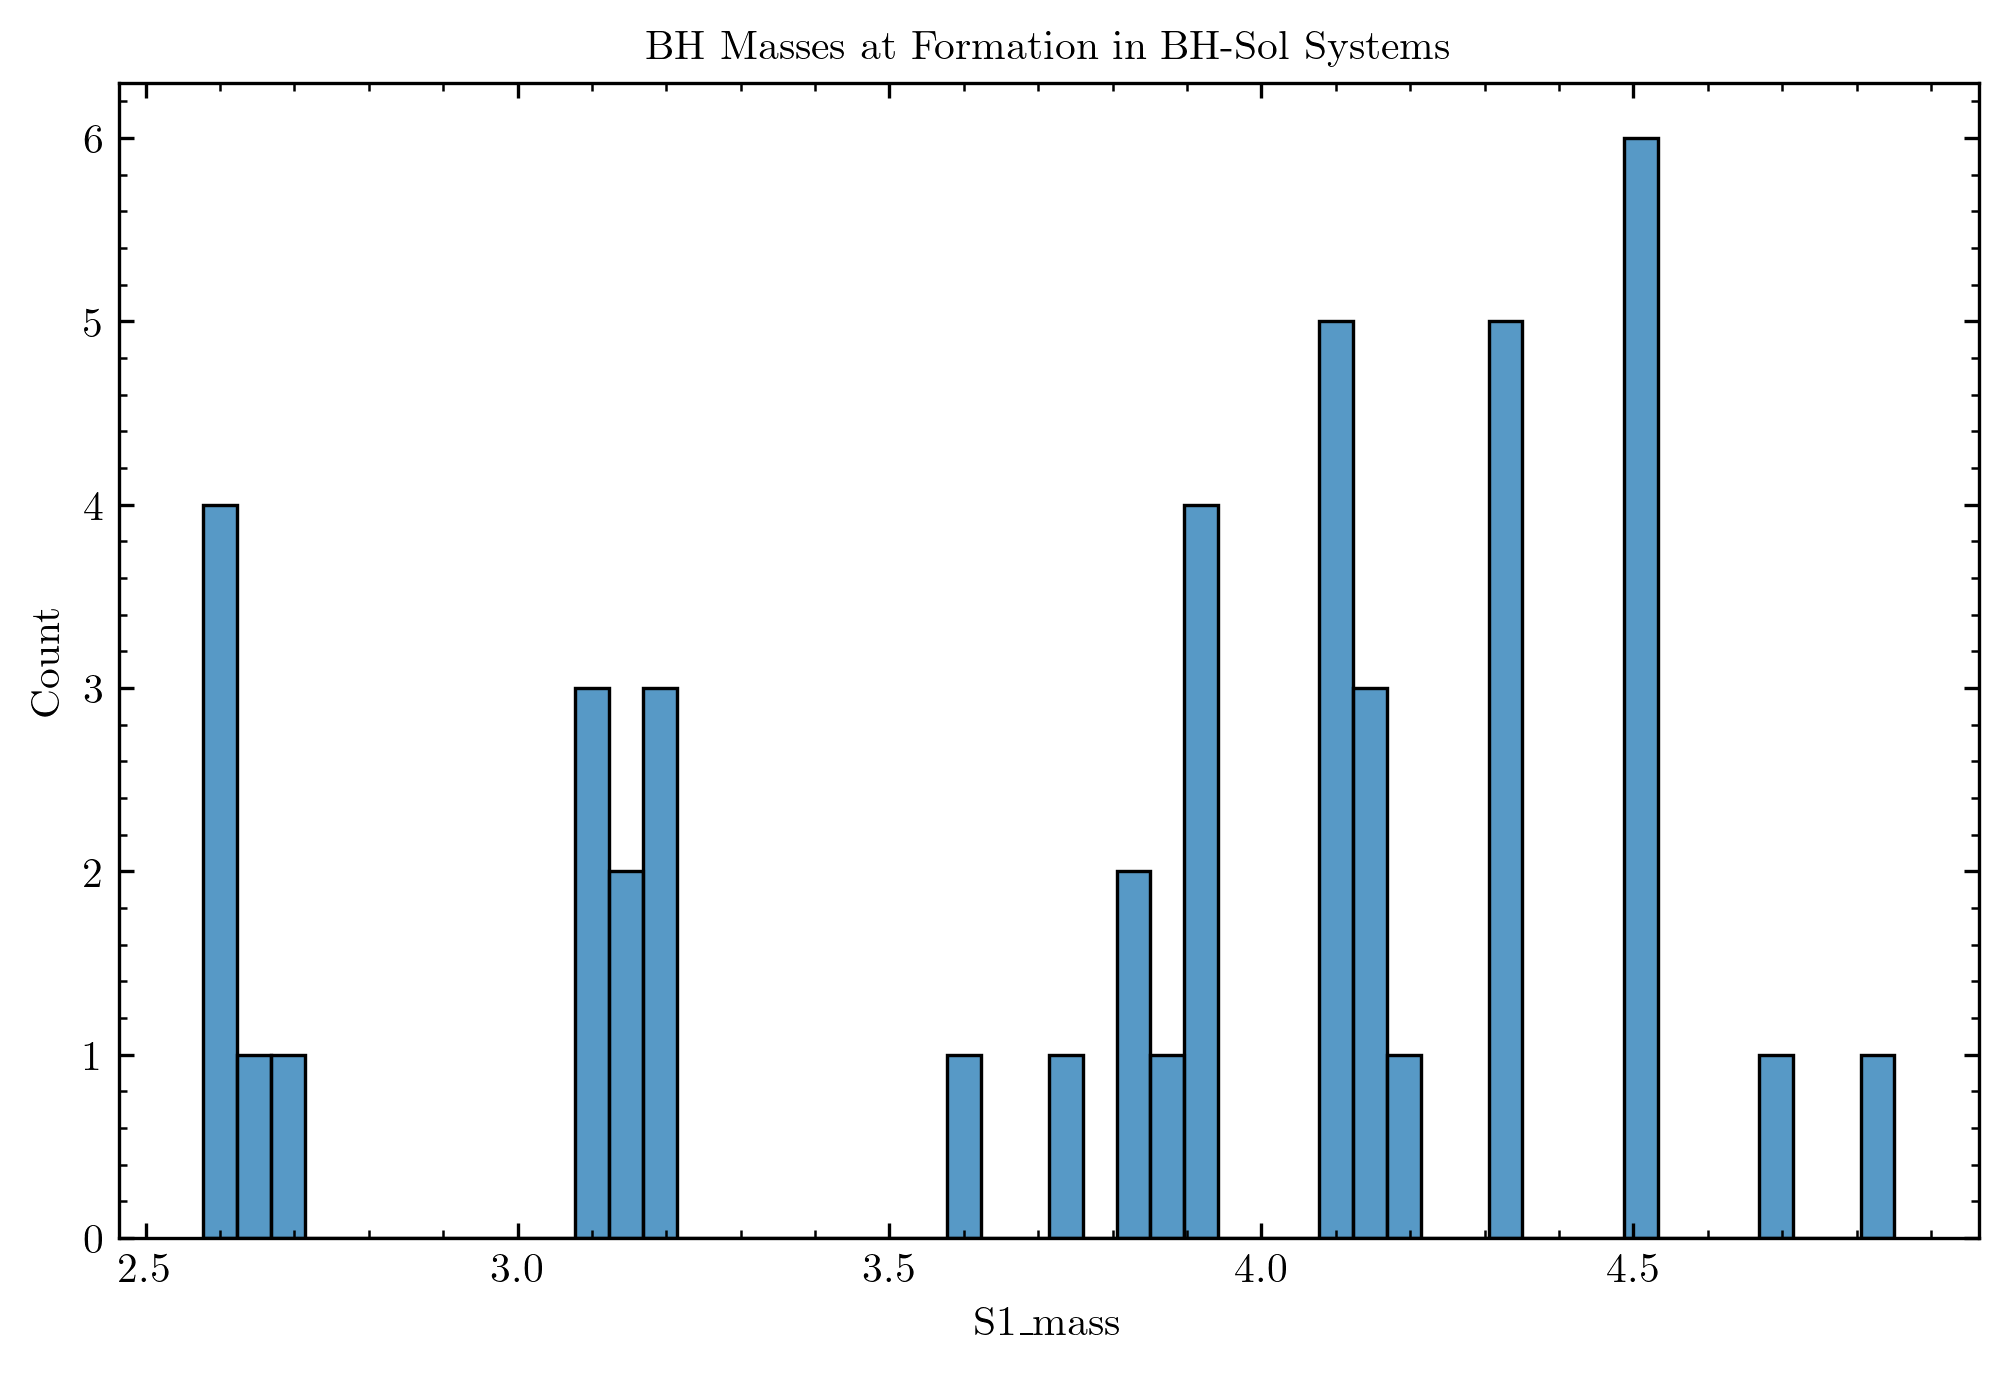

In [31]:
basicColHist(bhSolRows,'S1_mass', title='BH Masses at Formation in BH-Sol Systems')

In [32]:
# basicColHist(bhSolRows,'orbital_period', saveFig=True, savePath=graphSave)

In [33]:
slimOP = bhSolRows[bhSolRows['orbital_period'] < 25]['orbital_period']

In [34]:
# genVarHist(slimOP, title='Orbtial Period in Init BH-Sol Systems', xLabel='Orbital Period (days)', saveFig=True, savePath=graphSave)

In [35]:
# HR_Diagram(bhSolRows,
#            'BhSol',
#            Star_Radius=15)

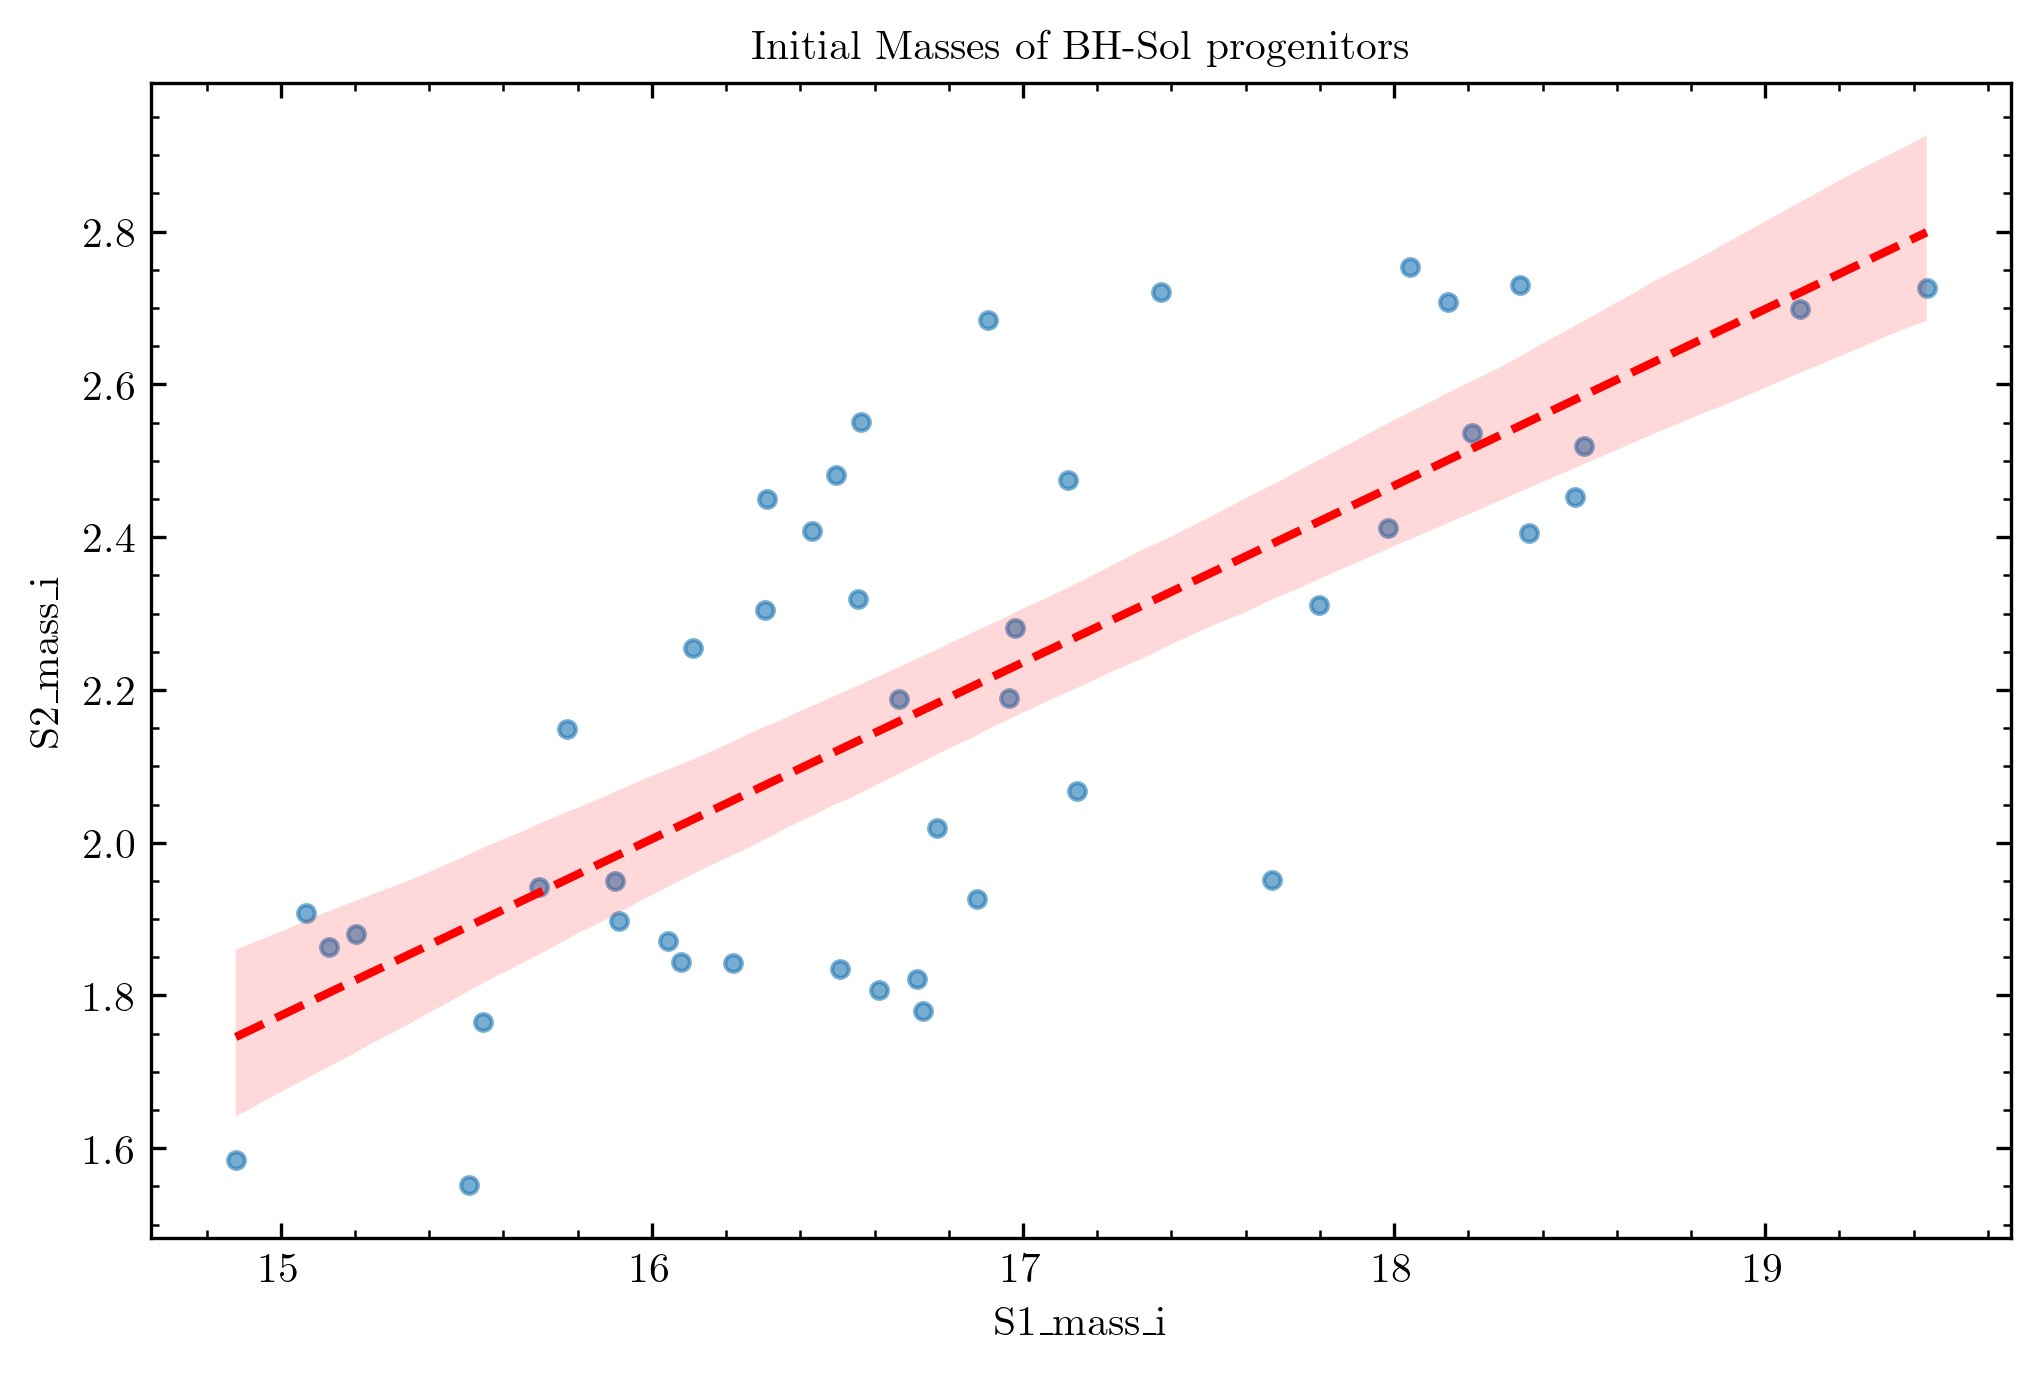

In [36]:
xVsY(df = pOneline, xvar= 'S1_mass_i', yvar='S2_mass_i', title='Initial Masses of BH-Sol progenitors', fit=True, saveFig=True, savePath=graphSave)
# xVsY(df = bhSolRows_Prev, xvar= 'S1_mass', yvar='S2_mass', title='Masses of BH-Sol progenitors', fit=True, saveFig=False, savePath=graphSave)

# xVsY(df = bhSolRows, xvar= 'S1_mass', yvar='S2_mass', title='BH-Sol Masses at Initial Formation', fit=True, saveFig=False, savePath=graphSave)

/tmp/ipykernel_1801999/989365877.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


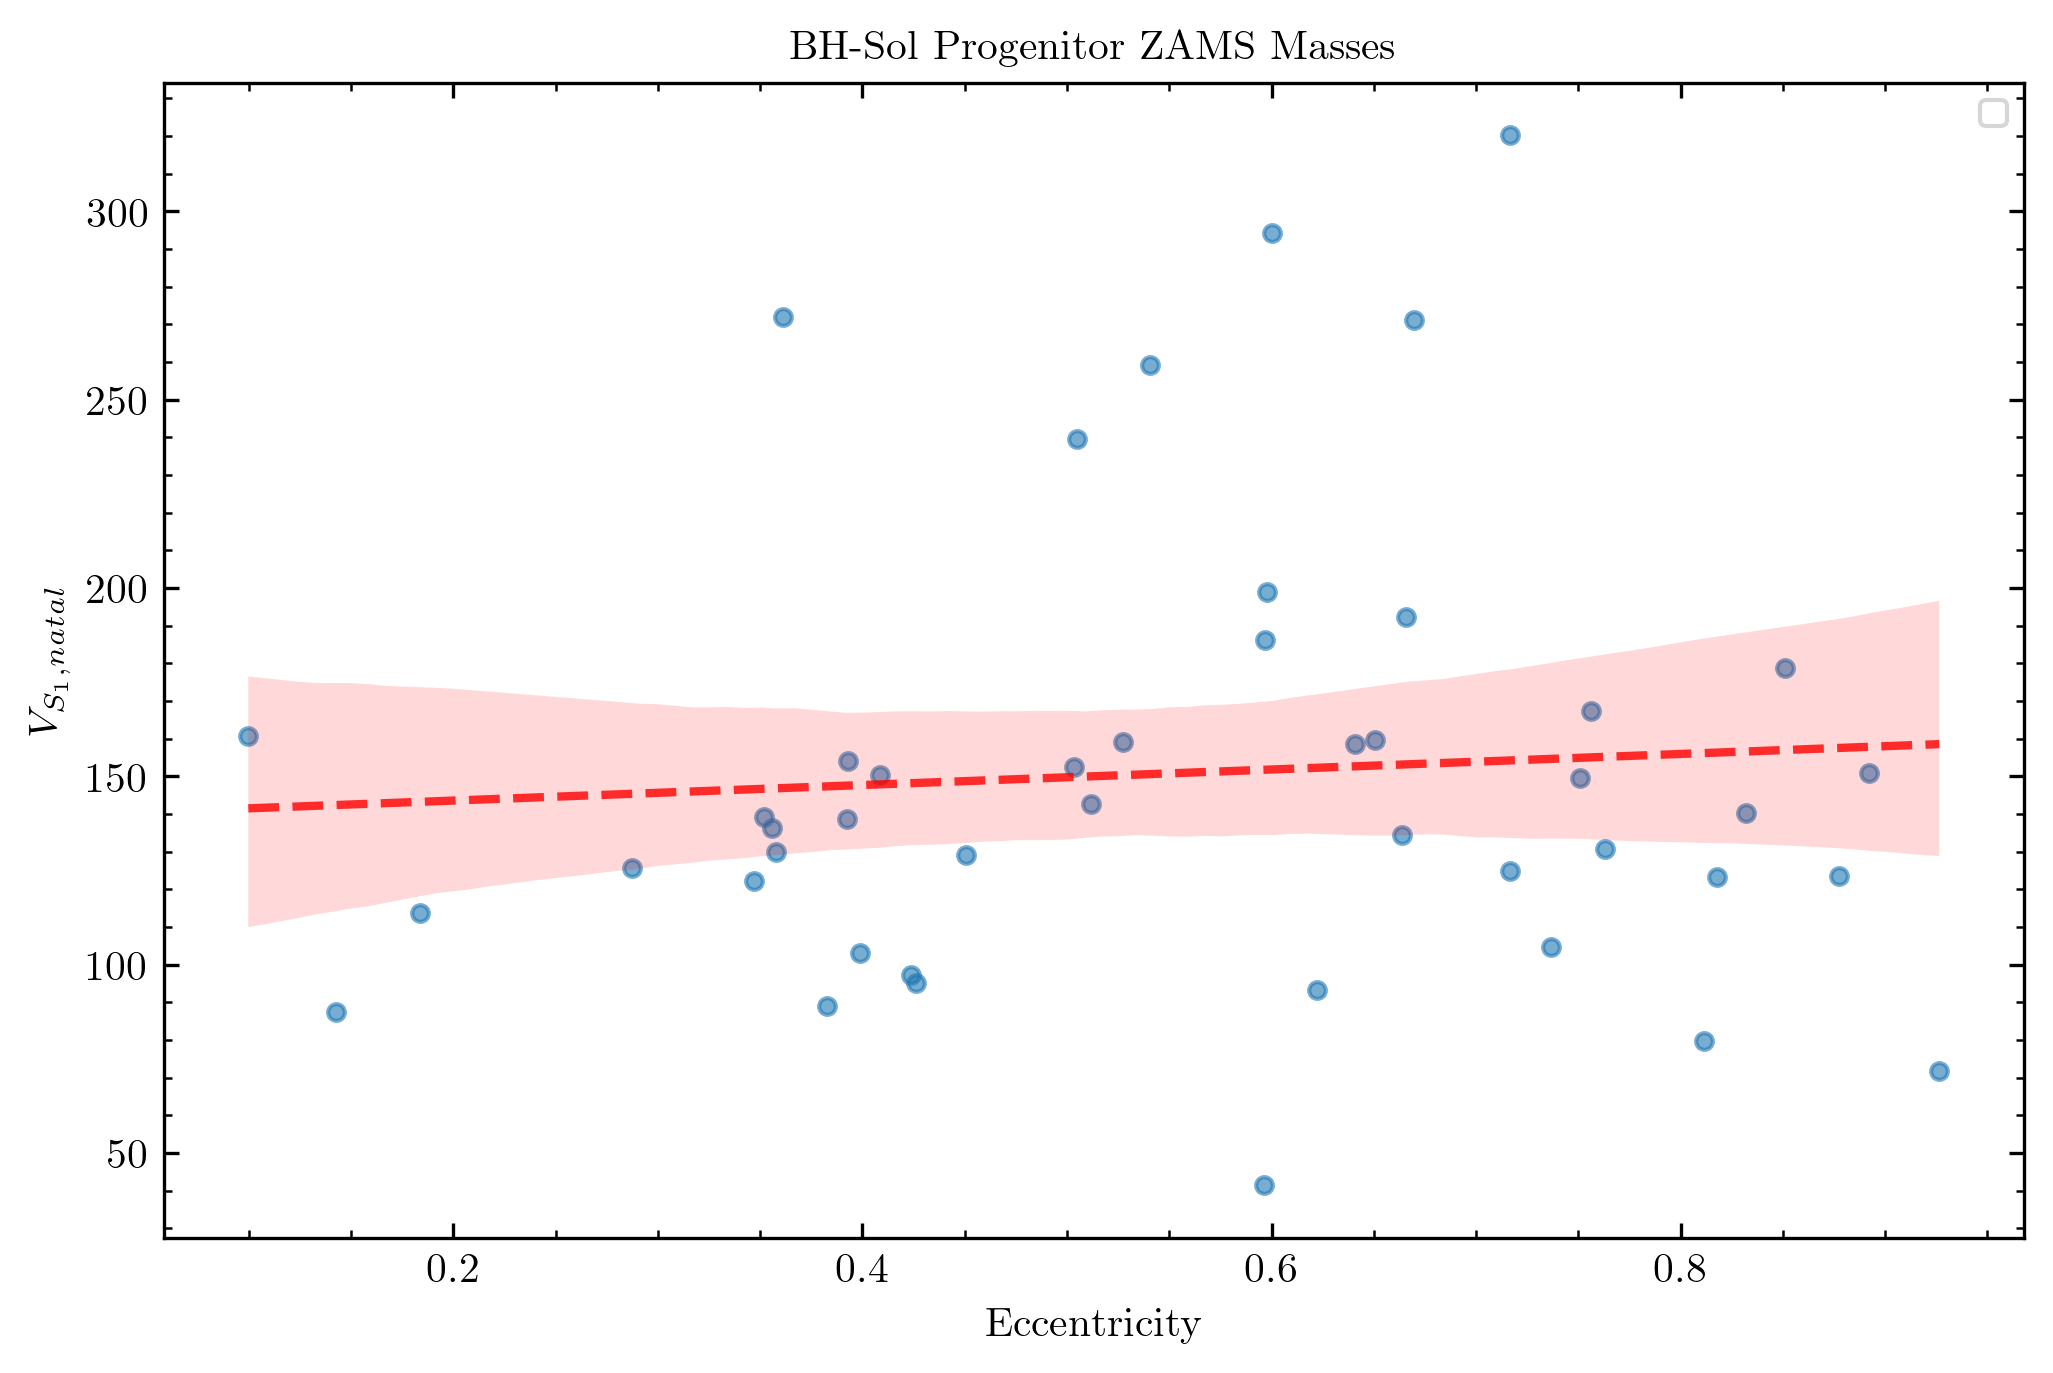

In [37]:
fig, ax = plt.subplots(figsize=(8, 5))

ci = 95

x1,y1 = bhSolRows['eccentricity'],pOneline['S1_natal_kick_velocity']
sns.regplot(x=x1, y=y1, ci=ci, ax=ax,
            line_kws={"color": "red", "linestyle": "--", "linewidth": 2, "alpha": .8},
            scatter_kws={"alpha": 0.6})

plt.legend(frameon=True)
plt.title('BH-Sol Progenitor ZAMS Masses')
plt.ylabel(r'$ V_{S_1, natal}$')
plt.xlabel('Eccentricity')

plt.savefig(graphSave / 'EccVNatalKickV.pgf', bbox_inches='tight')

plt.show()

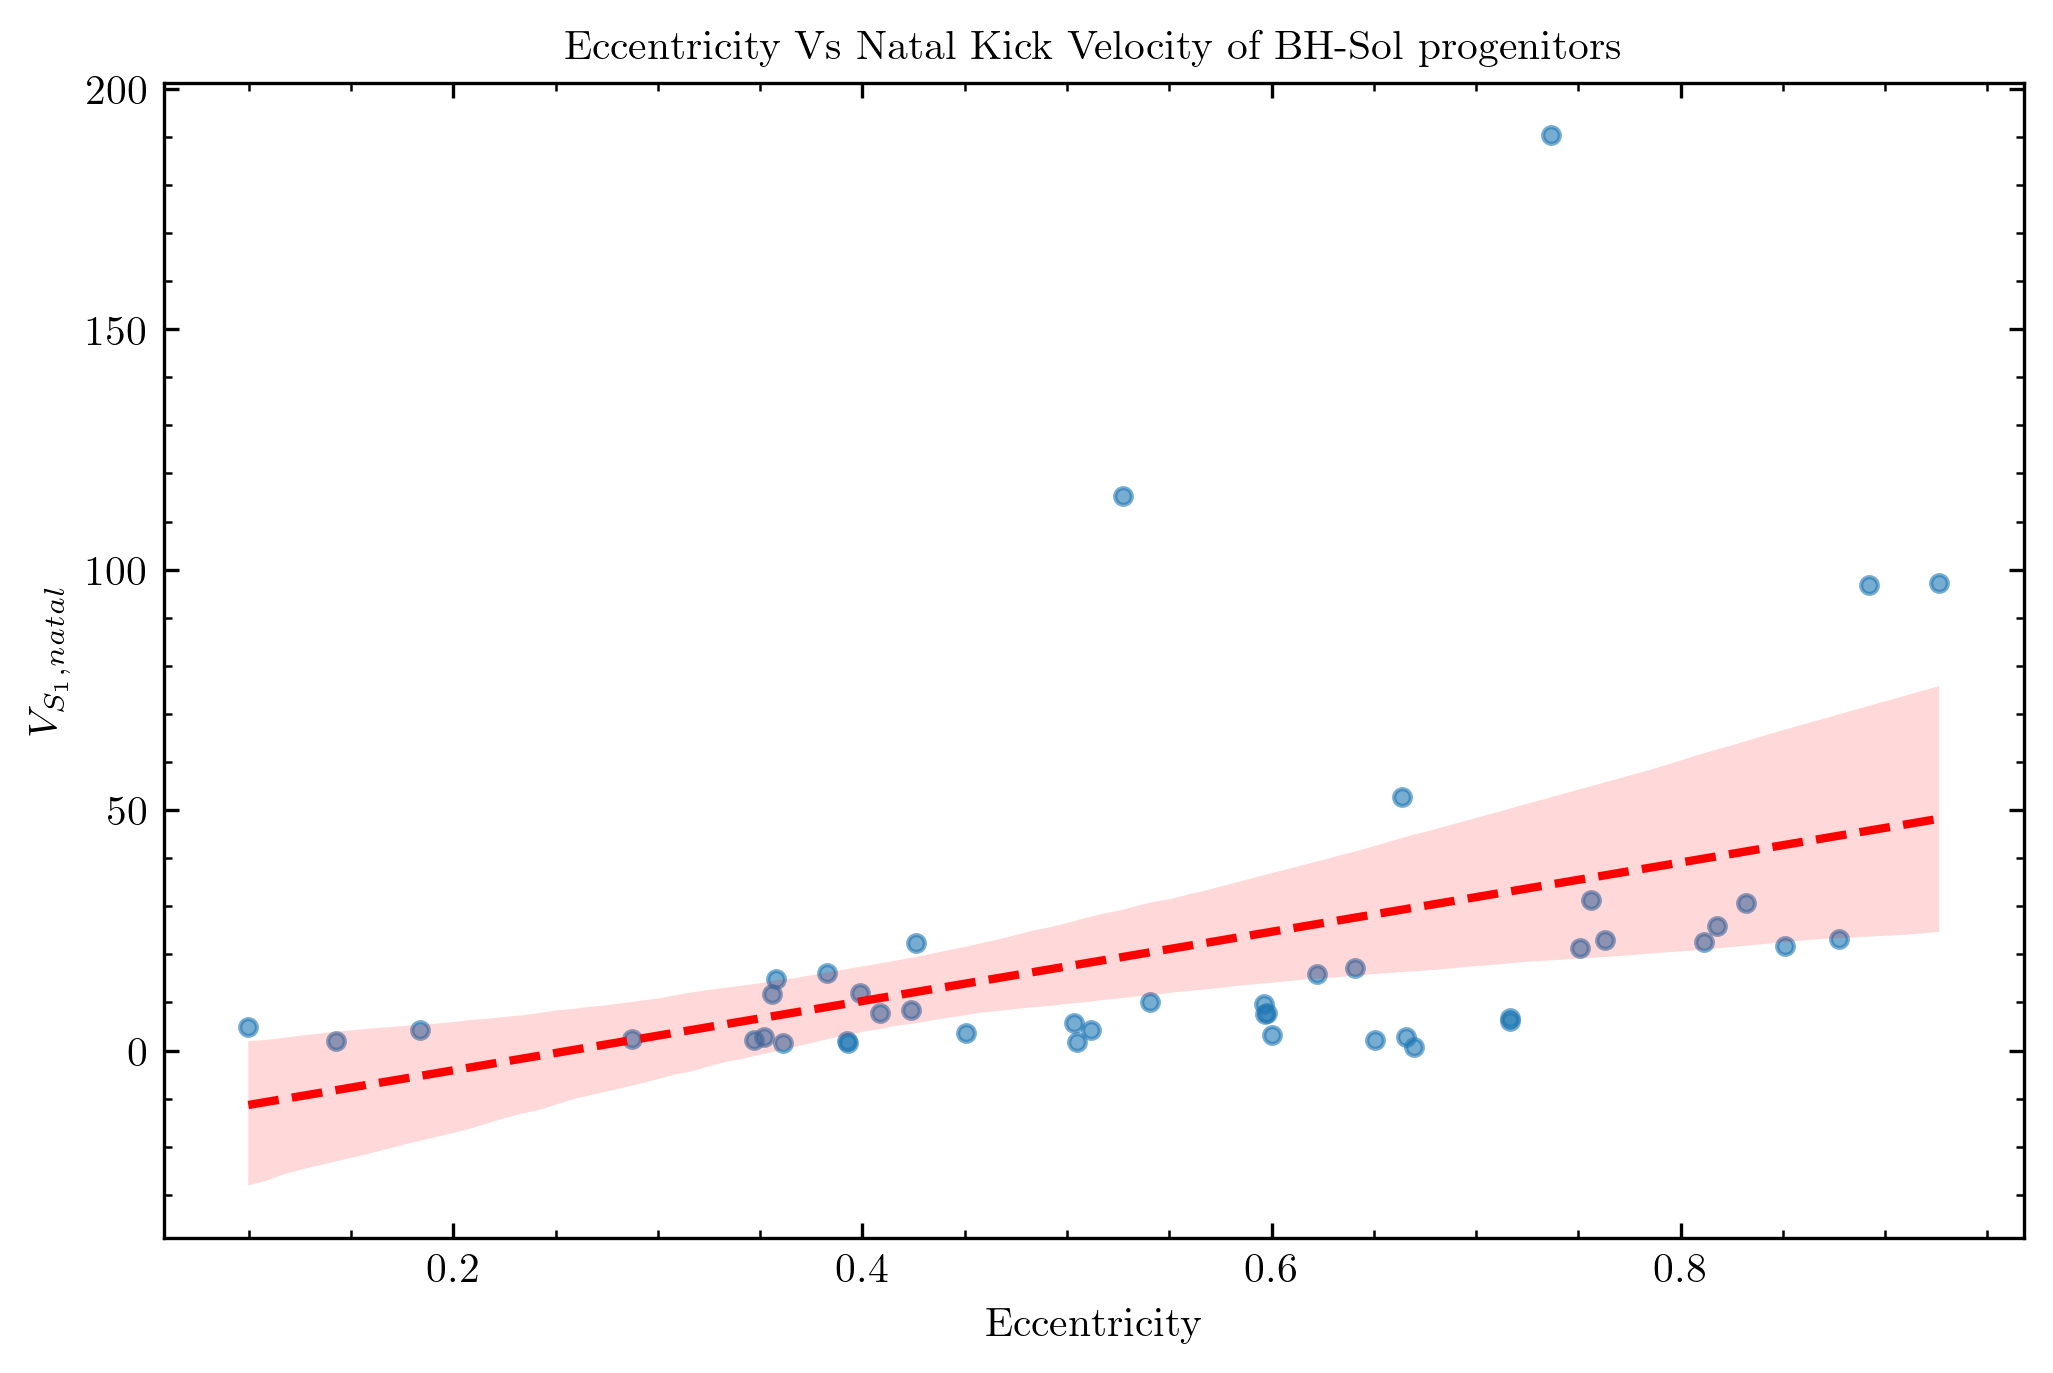

In [38]:
xVsY(xvar= bhSolRows['eccentricity'], yvar=bhSolRows['orbital_period'], title='Eccentricity Vs Natal Kick Velocity of BH-Sol progenitors', xLabel='Eccentricity', yLabel=r'$ V_{S_1, natal}$', fit=True, saveFig=False, savePath=graphSave)


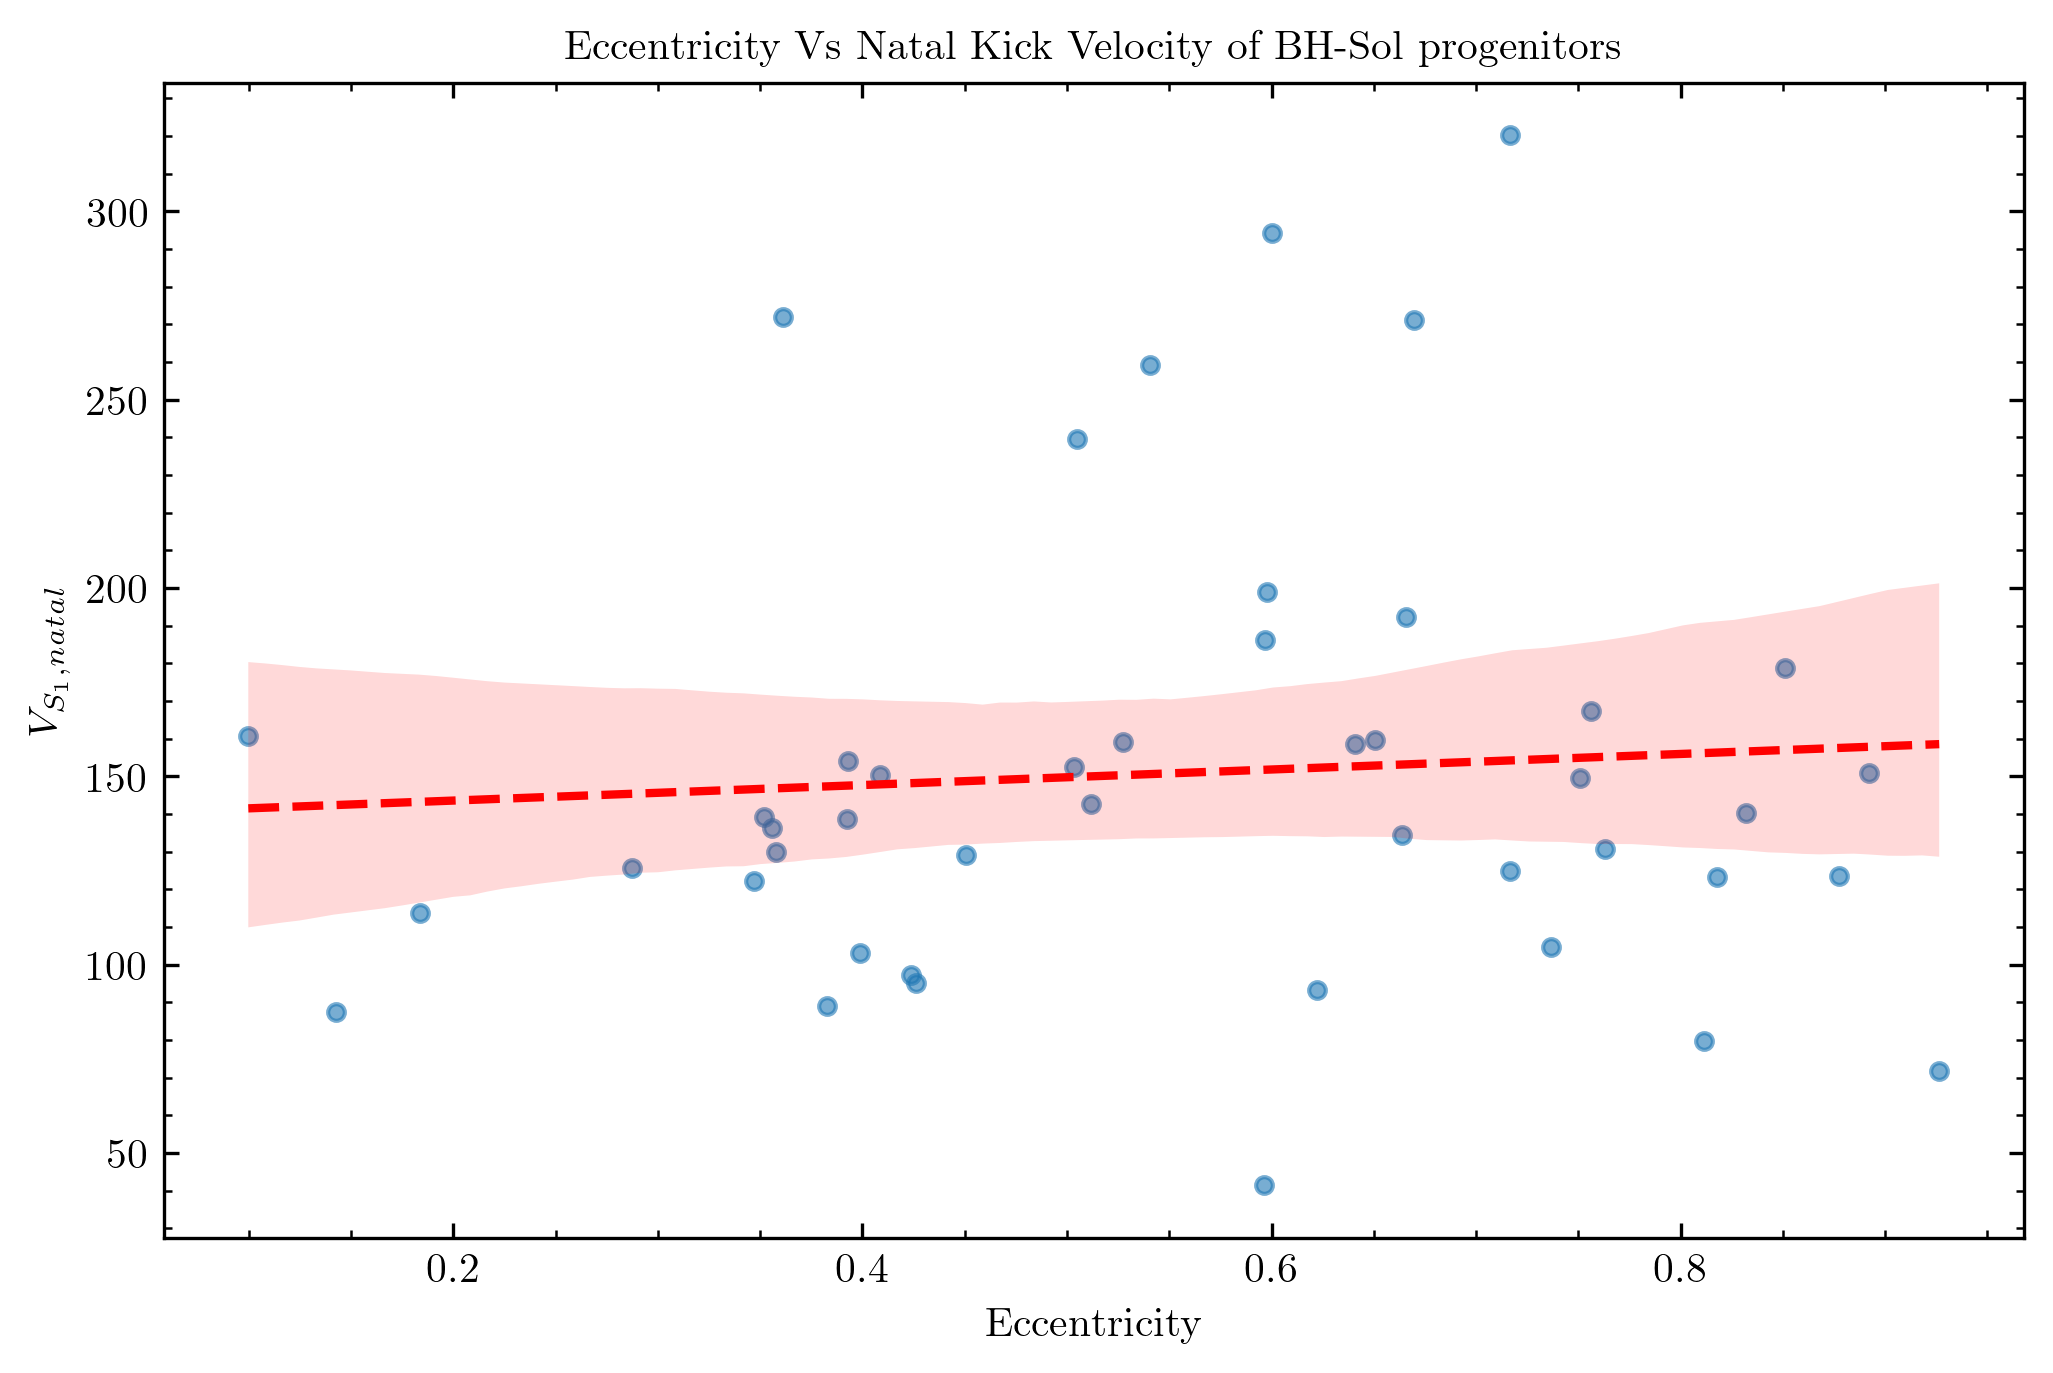

In [39]:
xVsY(xvar= bhSolRows['eccentricity'], yvar=pOneline['S1_natal_kick_velocity'], title='Eccentricity Vs Natal Kick Velocity of BH-Sol progenitors', xLabel='Eccentricity', yLabel=r'$ V_{S_1, natal}$', fit=True, saveFig=True, savePath=graphSave)

In [40]:
bhSolRows_Prev_02Z = bhSolRows_Prev_02Z.loc[bhSolRows_02Z.index.to_list()]

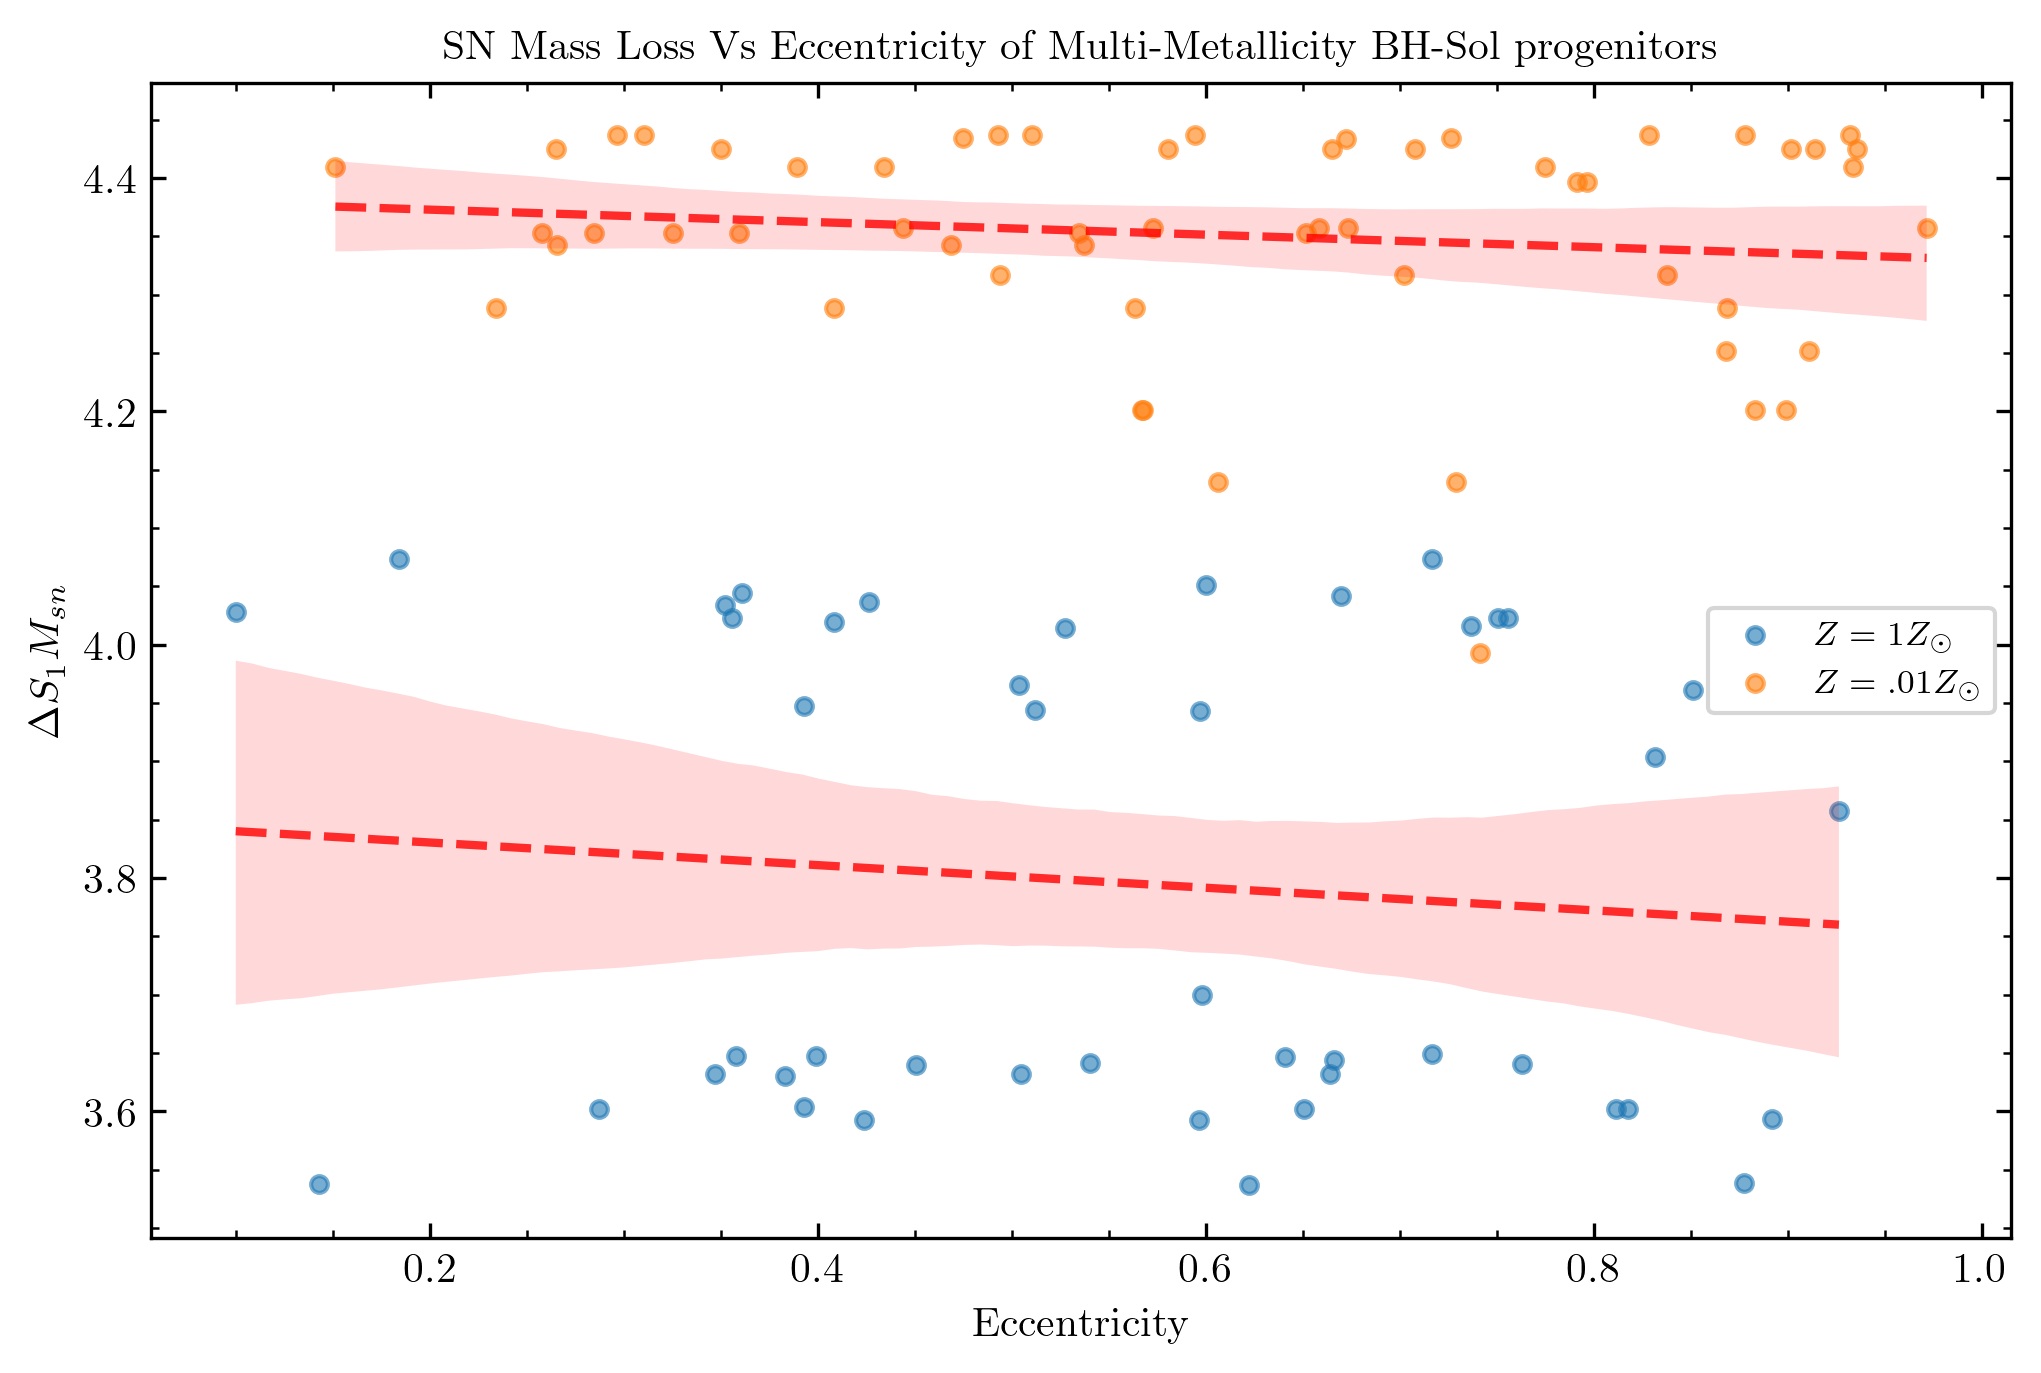

In [41]:
fig, ax = plt.subplots(figsize=(8, 5))

ci = 95

x1,y1 = bhSolRows['eccentricity'],(bhSolRows_Prev['S1_mass'] - bhSolRows['S1_mass'])
x2,y2 = bhSolRows_02Z['eccentricity'],(bhSolRows_Prev_02Z['S1_mass'] - bhSolRows_02Z['S1_mass'])

sns.regplot(x=x1, y=y1, ci=ci, ax=ax,
            line_kws={"color": "red", "linestyle": "--", "linewidth": 2, "alpha": .8},
            scatter_kws={"alpha": 0.6}, label=r"$Z = 1Z_{\odot}$")

sns.regplot(x=x2, y=y2, ci=ci, ax=ax,
            line_kws={"color": "red", "linestyle": "--", "linewidth": 2, "alpha": .8},
            scatter_kws={"alpha": 0.6}, label=r"$Z = .01Z_{\odot}$")

plt.legend(frameon=True)
plt.title('SN Mass Loss Vs Eccentricity of Multi-Metallicity BH-Sol progenitors')
plt.ylabel(r'$\Delta S_1 M_{sn}$')
plt.xlabel('Eccentricity')

plt.savefig(graphSave / 'MLvEcc_MultiMetal.pgf', bbox_inches='tight')

plt.show()

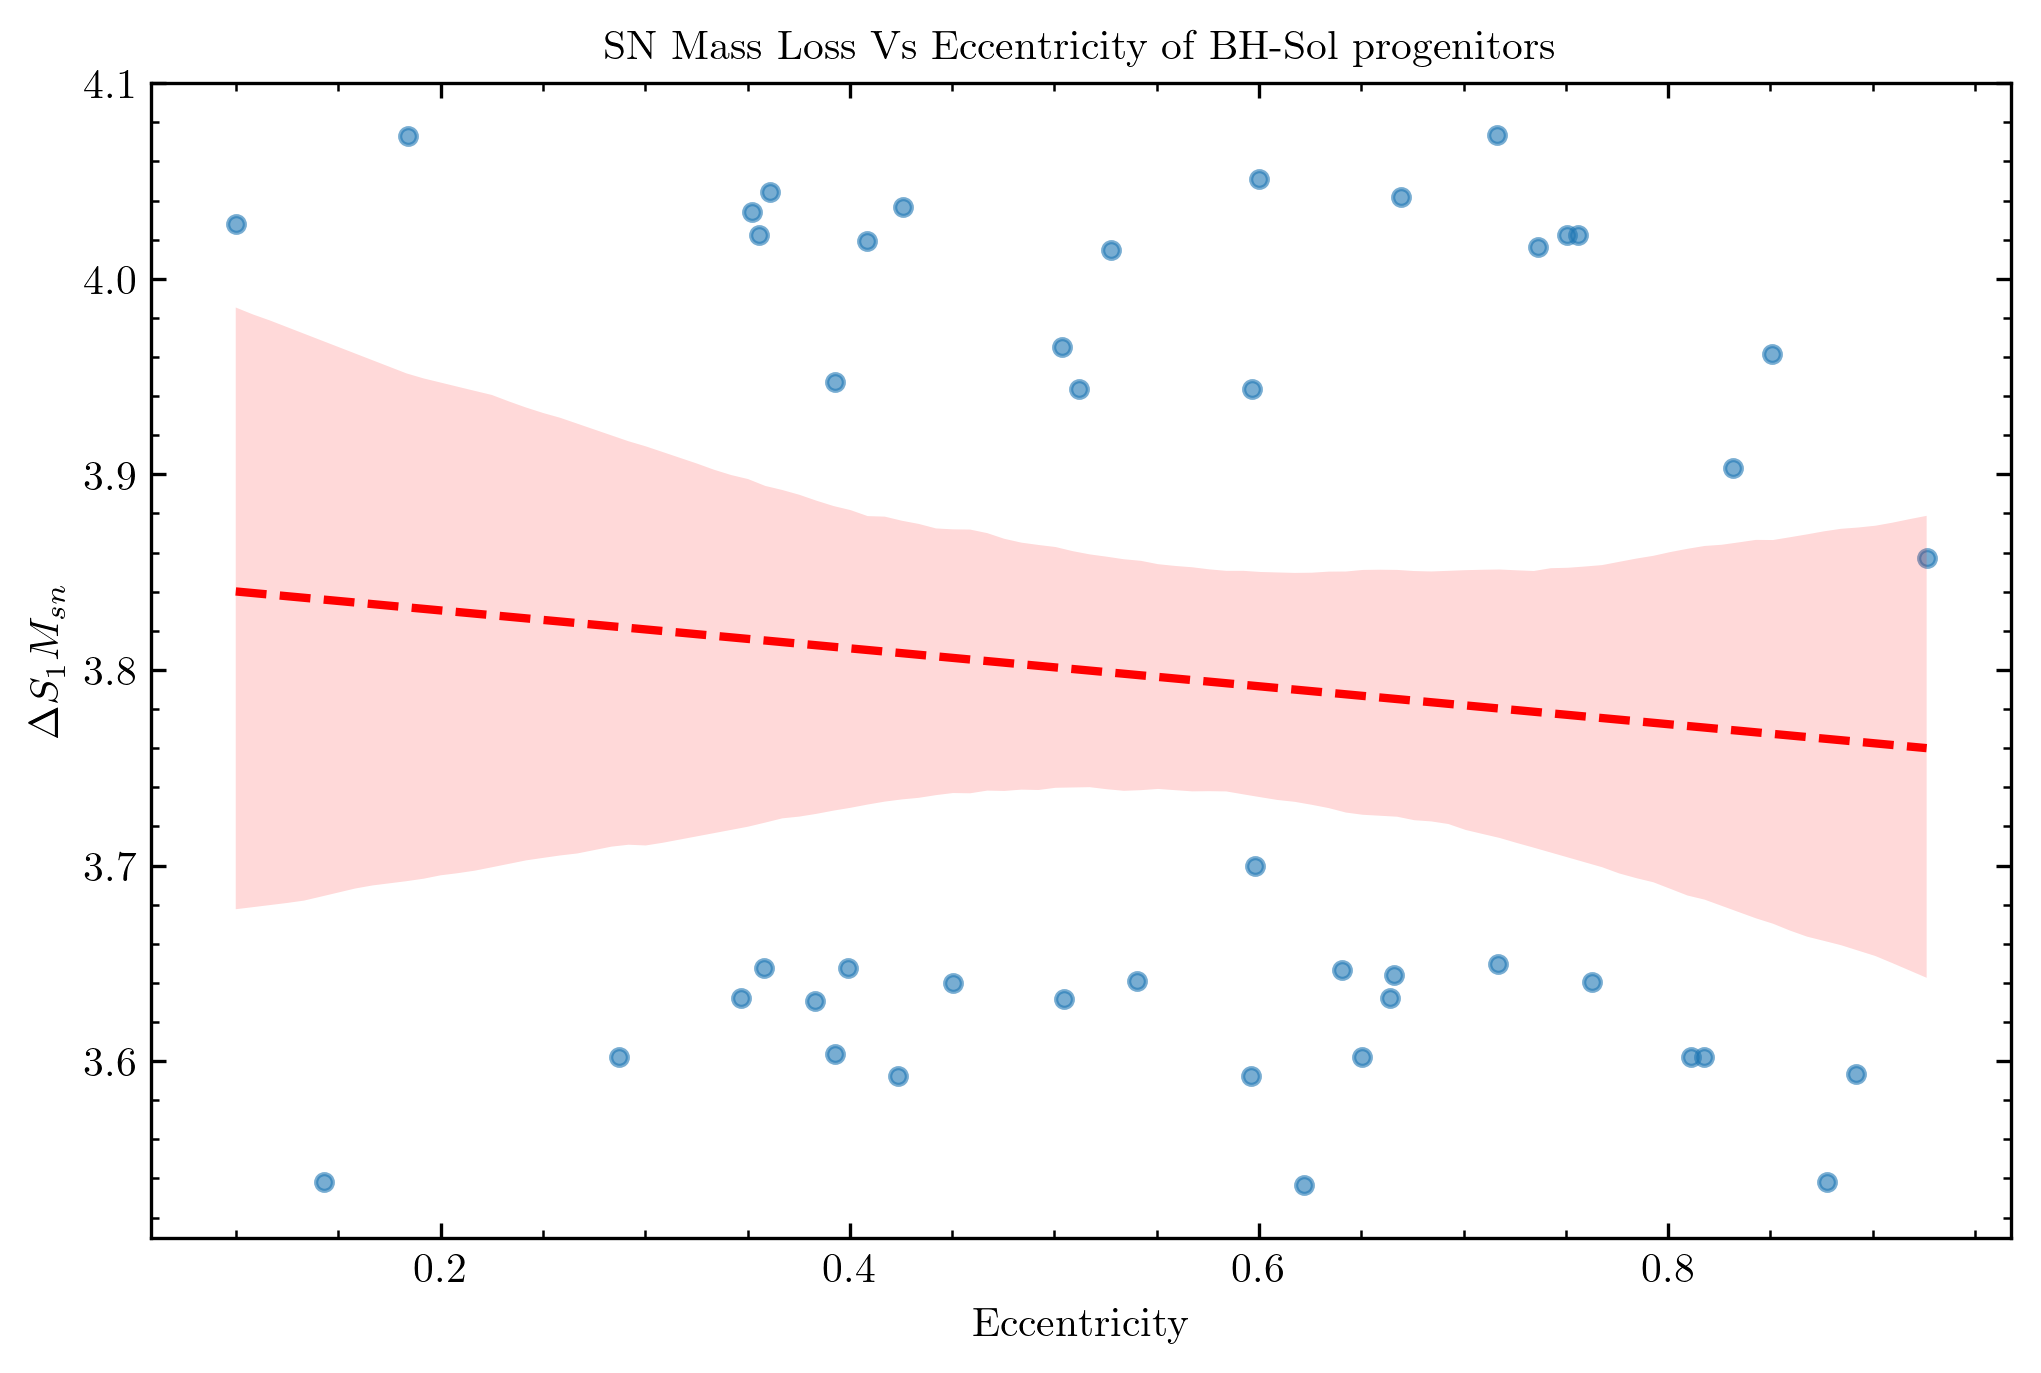

In [42]:
xVsY(xvar= bhSolRows['eccentricity'], yvar=(bhSolRows_Prev['S1_mass'] - bhSolRows['S1_mass']), title='SN Mass Loss Vs Eccentricity of BH-Sol progenitors', yLabel=r'$\Delta S_1 M_{sn}$', xLabel='Eccentricity', fit=True, saveFig=True, savePath=graphSave)

In [43]:
bhSolRows

,binary_index,state,event,time,orbital_period,eccentricity,lg_mtransfer_rate,step_names,step_times,S1_state,...,S2_he_core_mass,S2_he_core_radius,S2_co_core_mass,S2_co_core_radius,S2_center_h1,S2_center_he4,S2_surface_h1,S2_surface_he4,S2_surf_avg_omega_div_omega_crit,S2_spin
0,22892,detached,NaN,4.498900e+09,1.494220,0.360938,NaN,step_SN,0.002222,BH,...,0.0,NaN,0.0,0.0,0.691616,0.294023,0.7155,0.270271,0.105856,3.023514
1,30640,detached,NaN,8.381730e+09,1.884652,0.142856,NaN,step_SN,0.004856,BH,...,0.0,NaN,0.0,0.0,0.696244,0.289355,0.7155,0.270271,0.125305,3.578513
2,98004,detached,NaN,9.548856e+09,2.740360,0.351989,NaN,step_SN,0.003183,BH,...,0.0,NaN,0.0,0.0,0.695545,0.290039,0.7155,0.270271,0.097579,2.769272
3,152104,detached,NaN,2.025330e+09,0.796016,0.669528,NaN,step_SN,0.001699,BH,...,0.0,NaN,0.0,0.0,0.705203,0.280193,0.7155,0.270271,0.032131,0.904615
4,197243,detached,NaN,8.824689e+09,3.317456,0.600119,NaN,step_SN,0.002589,BH,...,0.0,NaN,0.0,0.0,0.695127,0.290483,0.7155,0.270271,0.080369,2.296414
5,214571,detached,NaN,9.934345e+09,6.844816,0.716792,NaN,step_SN,0.003830,BH,...,0.0,NaN,0.0,0.0,0.701769,0.283705,0.7155,0.270271,0.033424,0.937796
6,217672,detached,NaN,9.226441e+09,7.859836,0.598014,NaN,step_SN,0.003460,BH,...,0.0,NaN,0.0,0.0,0.704175,0.281255,0.7155,0.270271,0.030181,0.845591
7,227670,detached,NaN,3.143854e+08,52.749603,0.663875,NaN,step_SN,0.004207,BH,...,0.0,NaN,0.0,0.0,0.698373,0.287186,0.7155,0.270271,0.039821,1.129760
8,234637,detached,NaN,8.256869e+09,15.899186,0.622247,NaN,step_SN,0.004924,BH,...,0.0,NaN,0.0,0.0,0.696121,0.289475,0.7155,0.270271,0.050934,1.452895
9,271714,detached,NaN,7.629761e+09,14.974814,0.357936,NaN,step_SN,0.003989,BH,...,0.0,NaN,0.0,0.0,0.696206,0.289376,0.7155,0.270271,0.048040,1.364186


In [44]:
bhSolRows_Prev

,binary_index,state,event,time,orbital_period,eccentricity,lg_mtransfer_rate,step_names,step_times,S1_state,...,S2_he_core_mass,S2_he_core_radius,S2_co_core_mass,S2_co_core_radius,S2_center_h1,S2_center_he4,S2_surface_h1,S2_surface_he4,S2_surf_avg_omega_div_omega_crit,S2_spin
0,22892,detached,CC1,4.498900e+09,1.658225,0.0,NaN,step_detached,0.868884,stripped_He_Core_He_depleted,...,0.0,NaN,0.0,0.0,0.691616,0.294023,0.7155,0.270271,0.105856,3.023514
1,30640,detached,CC1,8.381730e+09,1.341035,0.0,NaN,step_detached,0.525430,stripped_He_Core_He_depleted,...,0.0,NaN,0.0,0.0,0.696244,0.289355,0.7155,0.270271,0.125305,3.578513
2,98004,detached,CC1,9.548856e+09,1.233283,0.0,NaN,step_detached,0.725547,stripped_He_Core_He_depleted,...,0.0,NaN,0.0,0.0,0.695545,0.290039,0.7155,0.270271,0.097579,2.769272
3,152104,detached,CC1,2.025330e+09,1.020614,0.0,NaN,step_detached,0.602951,stripped_He_Core_C_depleted,...,0.0,NaN,0.0,0.0,0.705203,0.280193,0.7155,0.270271,0.032131,0.904615
4,197243,detached,CC1,8.824689e+09,2.344240,0.0,NaN,step_detached,0.709911,stripped_He_Core_He_depleted,...,0.0,NaN,0.0,0.0,0.695127,0.290483,0.7155,0.270271,0.080369,2.296414
5,214571,detached,CC1,9.934345e+09,11.366438,0.0,NaN,step_detached,0.419060,stripped_He_Core_He_depleted,...,0.0,NaN,0.0,0.0,0.701769,0.283705,0.7155,0.270271,0.033424,0.937796
6,217672,detached,CC1,9.226441e+09,11.848820,0.0,NaN,step_detached,0.412706,stripped_He_Core_C_depleted,...,0.0,NaN,0.0,0.0,0.704175,0.281255,0.7155,0.270271,0.030181,0.845591
7,227670,detached,CC1,3.143854e+08,64.995027,0.0,NaN,step_detached,0.391972,stripped_He_Core_He_depleted,...,0.0,NaN,0.0,0.0,0.698373,0.287186,0.7155,0.270271,0.039821,1.129760
8,234637,detached,CC1,8.256869e+09,22.432903,0.0,NaN,step_detached,0.415221,stripped_He_Core_He_depleted,...,0.0,NaN,0.0,0.0,0.696121,0.289475,0.7155,0.270271,0.050934,1.452895
9,271714,detached,CC1,7.629761e+09,9.074883,0.0,NaN,step_detached,0.423288,stripped_He_Core_He_depleted,...,0.0,NaN,0.0,0.0,0.696206,0.289376,0.7155,0.270271,0.048040,1.364186


In [45]:
(bhSolRows_Prev['S1_mass'] -bhSolRows['S1_mass'])

0     4.044464
1     3.538047
2     4.033974
3     4.041816
4     4.051239
5     3.649396
6     3.699837
7     3.632055
8     3.536414
9     3.647638
10    3.646785
11    4.073215
12    3.601889
13    3.641097
14    3.943646
15    3.602270
16    4.016101
18    4.022477
19    3.903475
20    3.640091
21    3.857159
22    3.593452
23    4.022477
24    3.602097
25    4.014632
26    3.603736
27    4.022477
28    3.647583
29    4.073270
30    3.630566
31    3.631904
32    3.965150
33    3.602335
34    3.643953
35    3.632062
36    3.592138
37    3.961602
38    4.019226
39    3.592227
40    3.538415
41    3.943400
42    3.947166
43    3.640209
44    4.036902
45    4.027863
Name: S1_mass, dtype: float64

In [46]:
# xVsY(useDF=False, xvar=pOneline['S1_mass_i'], yvar=bhSolRows['eccentricity'], fit=True)

In [47]:
# fig, ax = plt.subplots(figsize=(8,5))

# var = 'S2_mass_i'
# sns.histplot(pOneline[var], bins=50, ax=ax)

# title = f'{var} of BH-Sol Systems'

# ax.set_title(title)
# ax.set_xlabel(var)
# ax.set_ylabel('Count')

# clean_name = title.replace(' ', '_').replace('/', '-') + '.pgf'
# plt.savefig(graphSave / clean_name, bbox_inches='tight')

# plt.show()

In [48]:
# fig, ax = plt.subplots(figsize=(8,5))

# var = 'S1_mass_i'
# sns.histplot(pOneline[var], bins=50, ax=ax)

# title = f'{var} of BH-Sol Systems'

# ax.set_title(title)
# ax.set_xlabel(var)
# ax.set_ylabel('Count')

# clean_name = title.replace(' ', '_').replace('/', '-') + '.pgf'
# plt.savefig(graphSave / clean_name, bbox_inches='tight')

# plt.show()

[ 0.23123458 -1.69487239]
[ 0.14874042 -0.15020399]


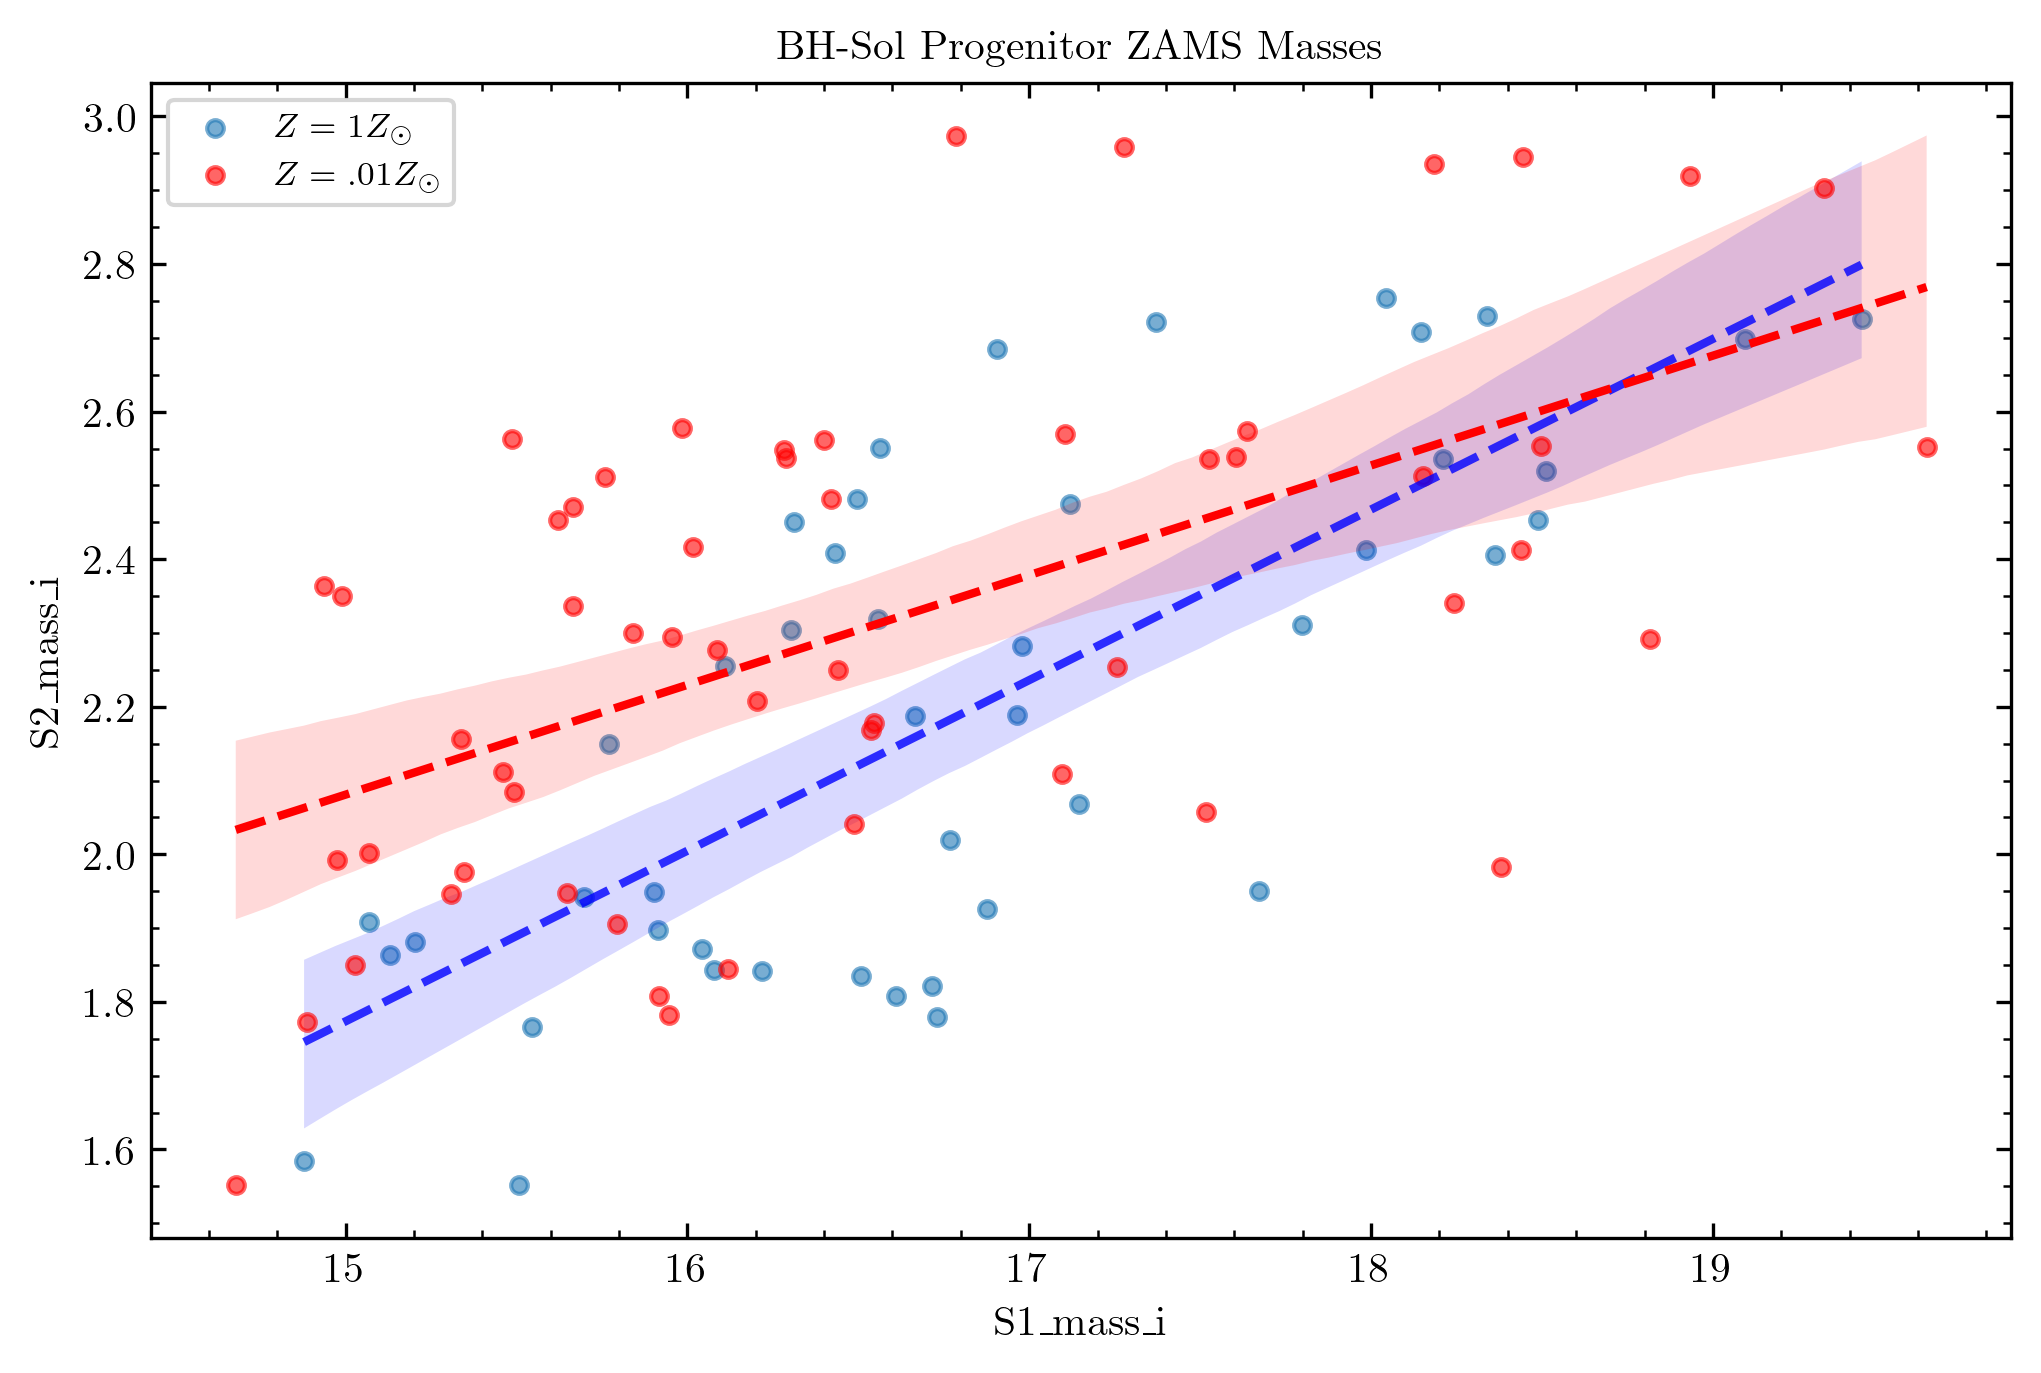

In [49]:
fig, ax = plt.subplots(figsize=(8, 5))

ci = 95

x1,y1 = pOneline['S1_mass_i'],pOneline['S2_mass_i']
x2,y2 = pOneline_02Z['S1_mass_i'],pOneline_02Z['S2_mass_i']

print(np.polyfit(x1,y1, 1))
print(np.polyfit(x2,y2, 1))

sns.regplot(x=x1, y=y1, ci=ci, ax=ax,
            line_kws={"color": "blue", "linestyle": "--", "linewidth": 2, "alpha": .8},
            scatter_kws={"alpha": 0.6}, label=r"$Z = 1Z_{\odot}$")

sns.regplot(x=x2, y=y2, ci=ci, ax=ax, color= 'red',
            line_kws={"color": "red", "linestyle": "--", "linewidth": 2},
            scatter_kws={"alpha": 0.6}, label=r"$Z = .01 Z_{\odot}$")


plt.legend(frameon=True)
plt.title('BH-Sol Progenitor ZAMS Masses')

plt.savefig(graphSave / 'ZsunVs_e02Zsun.pgf', format ='pgf', transparent =True, bbox_inches='tight')

plt.show()

In [50]:
pOneline['S2_mass_i'].describe()

count    45.000000
mean      2.195909
std       0.348479
min       1.551266
25%       1.880662
50%       2.188940
75%       2.474821
max       2.753904
Name: S2_mass_i, dtype: float64

In [51]:
pOneline_merged

,state_i,event_i,time_i,orbital_period_i,eccentricity_i,lg_mtransfer_rate_i,step_names_i,step_times_i,S1_state_i,S1_mass_i,...,interp_class_CO_HMS_RLO,interp_class_CO_HeMS,interp_class_CO_HeMS_RLO,mt_history_HMS_HMS,mt_history_CO_HMS_RLO,mt_history_CO_HeMS,mt_history_CO_HeMS_RLO,FAILED,WARNING,metallicity
binary_index,,,,,,,,,,,,,,,,,,,,,
0,detached,ZAMS,7.782037e+09,3957.766065,0.906189,NaN,initial_cond,0.0,H-rich_Core_H_burning,16.275477,...,NaN,NaN,NaN,Unstable RLOF during postMS,NaN,NaN,NaN,0,1,1.0
1,detached,ZAMS,1.331356e+10,4315.464597,0.626028,NaN,initial_cond,0.0,H-rich_Core_H_burning,18.193304,...,NaN,NaN,NaN,Unstable RLOF during postMS,NaN,NaN,NaN,0,1,1.0
2,detached,ZAMS,1.191930e+09,4094.415836,0.826915,NaN,initial_cond,0.0,H-rich_Core_H_burning,19.547507,...,NaN,NaN,NaN,Unstable RLOF during postMS,NaN,NaN,NaN,0,1,1.0
3,detached,ZAMS,1.740057e+09,4321.346381,0.676240,NaN,initial_cond,0.0,H-rich_Core_H_burning,17.393802,...,NaN,NaN,NaN,Unstable RLOF during postMS,NaN,NaN,NaN,0,1,1.0
4,detached,ZAMS,1.299998e+10,3915.048011,0.853262,NaN,initial_cond,0.0,H-rich_Core_H_burning,18.345373,...,NaN,NaN,NaN,Unstable RLOF during postMS,NaN,NaN,NaN,0,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233,detached,ZAMS,8.365818e+09,3956.430109,0.963147,NaN,initial_cond,0.0,H-rich_Core_H_burning,16.863457,...,NaN,NaN,NaN,Unstable RLOF during postMS,NaN,NaN,NaN,0,1,1.0
234,detached,ZAMS,2.084565e+09,4019.145979,0.905204,NaN,initial_cond,0.0,H-rich_Core_H_burning,18.497876,...,NaN,NaN,NaN,Unstable RLOF during postMS,NaN,NaN,NaN,0,1,1.0
235,detached,ZAMS,5.851540e+09,4041.362731,0.698113,NaN,initial_cond,0.0,H-rich_Core_H_burning,16.353732,...,NaN,NaN,NaN,Unstable RLOF during postMS,NaN,NaN,NaN,0,1,1.0


[ 0.23123458 -1.69487239]
[ 0.1575119  -0.70052789]


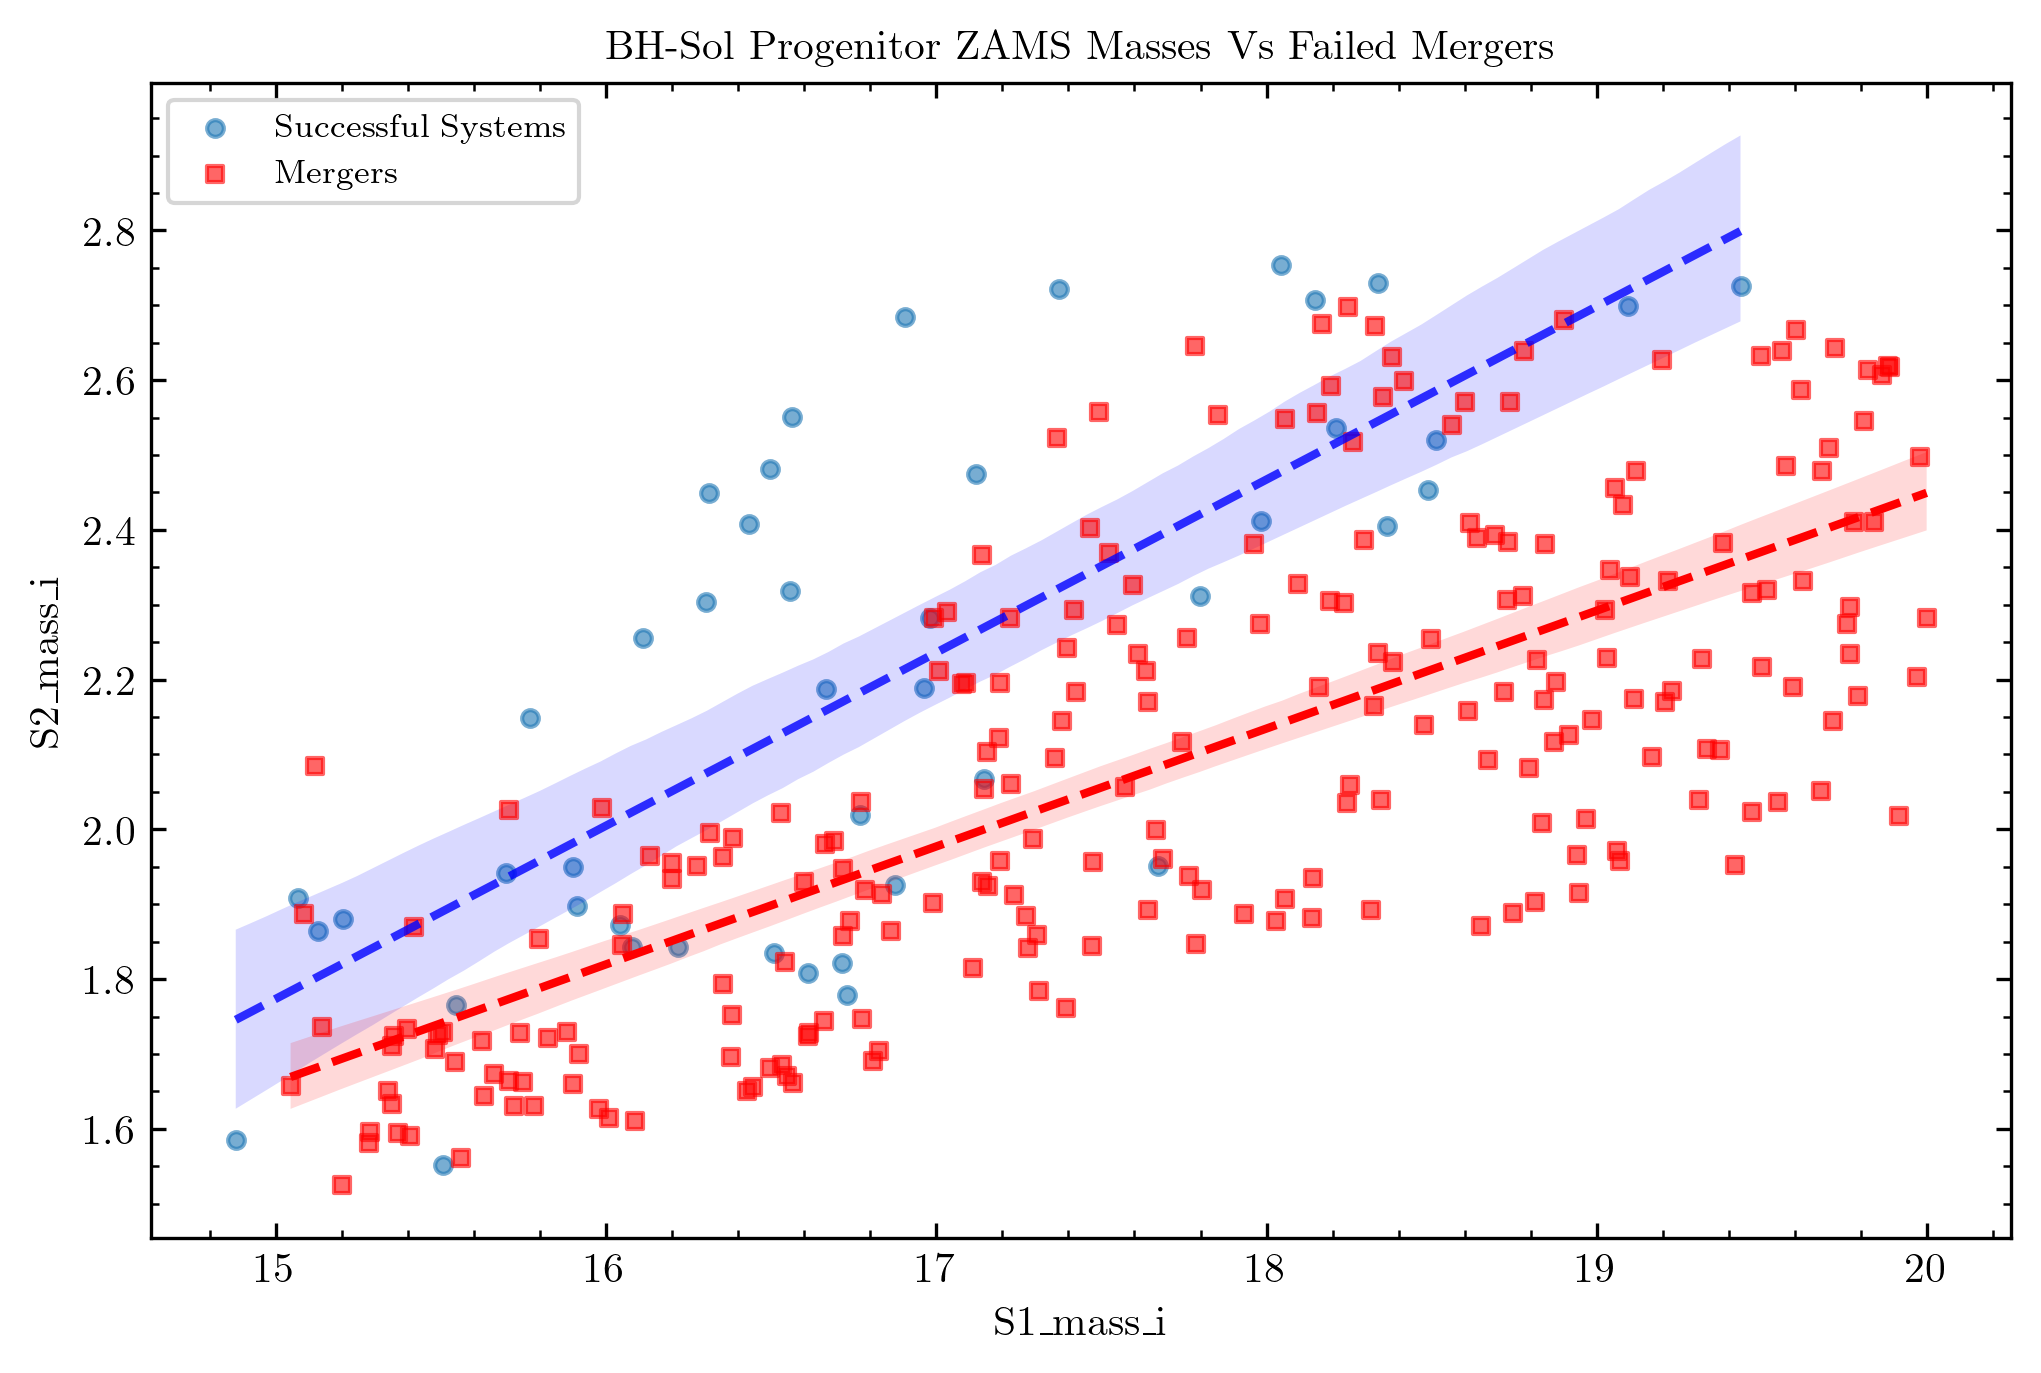

In [52]:
fig, ax = plt.subplots(figsize=(8, 5))

ci = 95


x1,y1 = pOneline['S1_mass_i'],pOneline['S2_mass_i']
x2,y2 = pOneline_merged['S1_mass_i'],pOneline_merged['S2_mass_i']

print(np.polyfit(x1,y1, 1))
print(np.polyfit(x2,y2, 1))

sns.regplot(x=x1, y=y1, ci=ci, ax=ax,
            line_kws={"color": "blue", "linestyle": "--", "linewidth": 2, "alpha": .8},
            scatter_kws={"alpha": 0.6}, label=r"Successful Systems")

sns.regplot(x=x2, y=y2, ci=ci, ax=ax, color= 'red', marker='s',
            line_kws={"color": "red", "linestyle": "--", "linewidth": 2},
            scatter_kws={"alpha": 0.6}, label=r"Mergers")


plt.legend(frameon=True)
plt.title('BH-Sol Progenitor ZAMS Masses Vs Failed Mergers')

plt.savefig(graphSave / 'BHSol_ProgenitorsVsFailedMergers.pgf', bbox_inches='tight')

plt.show()

[0.10082268 1.98694574]
[0.26727867 1.67415401]


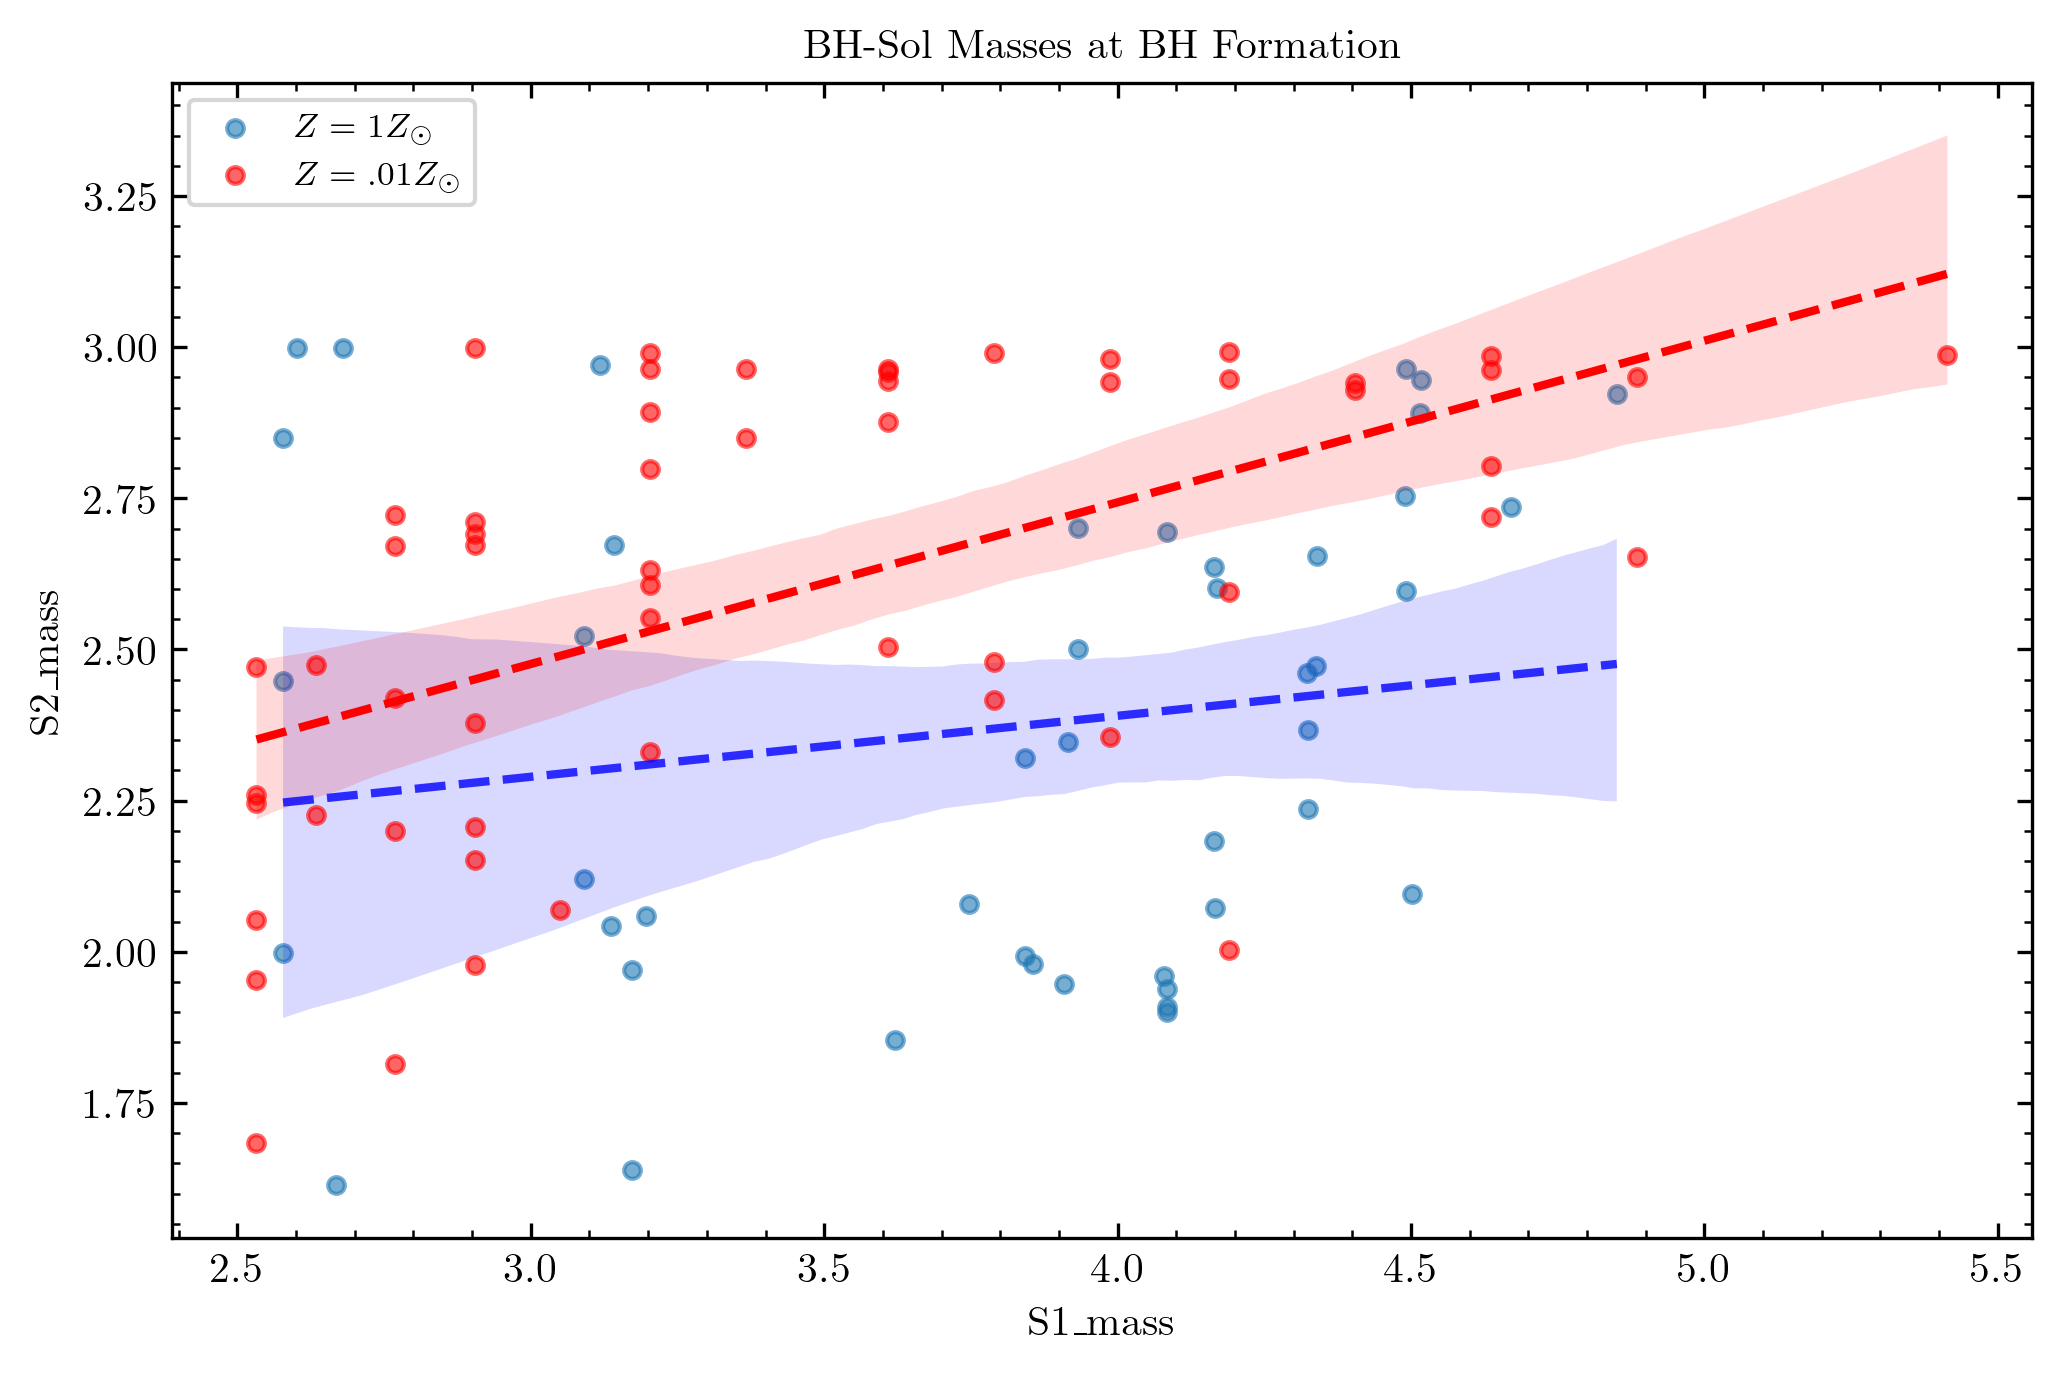

In [53]:
fig, ax = plt.subplots(figsize=(8, 5))

ci = 95

x1,y1 = bhSolRows['S1_mass'],bhSolRows['S2_mass']
x2,y2 = bhSolRows_02Z['S1_mass'],bhSolRows_02Z['S2_mass']

print(np.polyfit(x1,y1, 1))
print(np.polyfit(x2,y2, 1))

sns.regplot(x=x1, y=y1, ci=ci, ax=ax,
            line_kws={"color": "blue", "linestyle": "--", "linewidth": 2, "alpha": .8},
            scatter_kws={"alpha": 0.6}, label=r"$Z = 1Z_{\odot}$")

sns.regplot(x=x2, y=y2, ci=ci, ax=ax, color= 'red',
            line_kws={"color": "red", "linestyle": "--", "linewidth": 2},
            scatter_kws={"alpha": 0.6}, label=r"$Z = .01 Z_{\odot}$")


plt.legend(frameon=True)
plt.title('BH-Sol Masses at BH Formation')

plt.savefig(graphSave / 'ZsunVs_e02Zsun_BHSol_Masses.pgf', bbox_inches='tight')

plt.show()

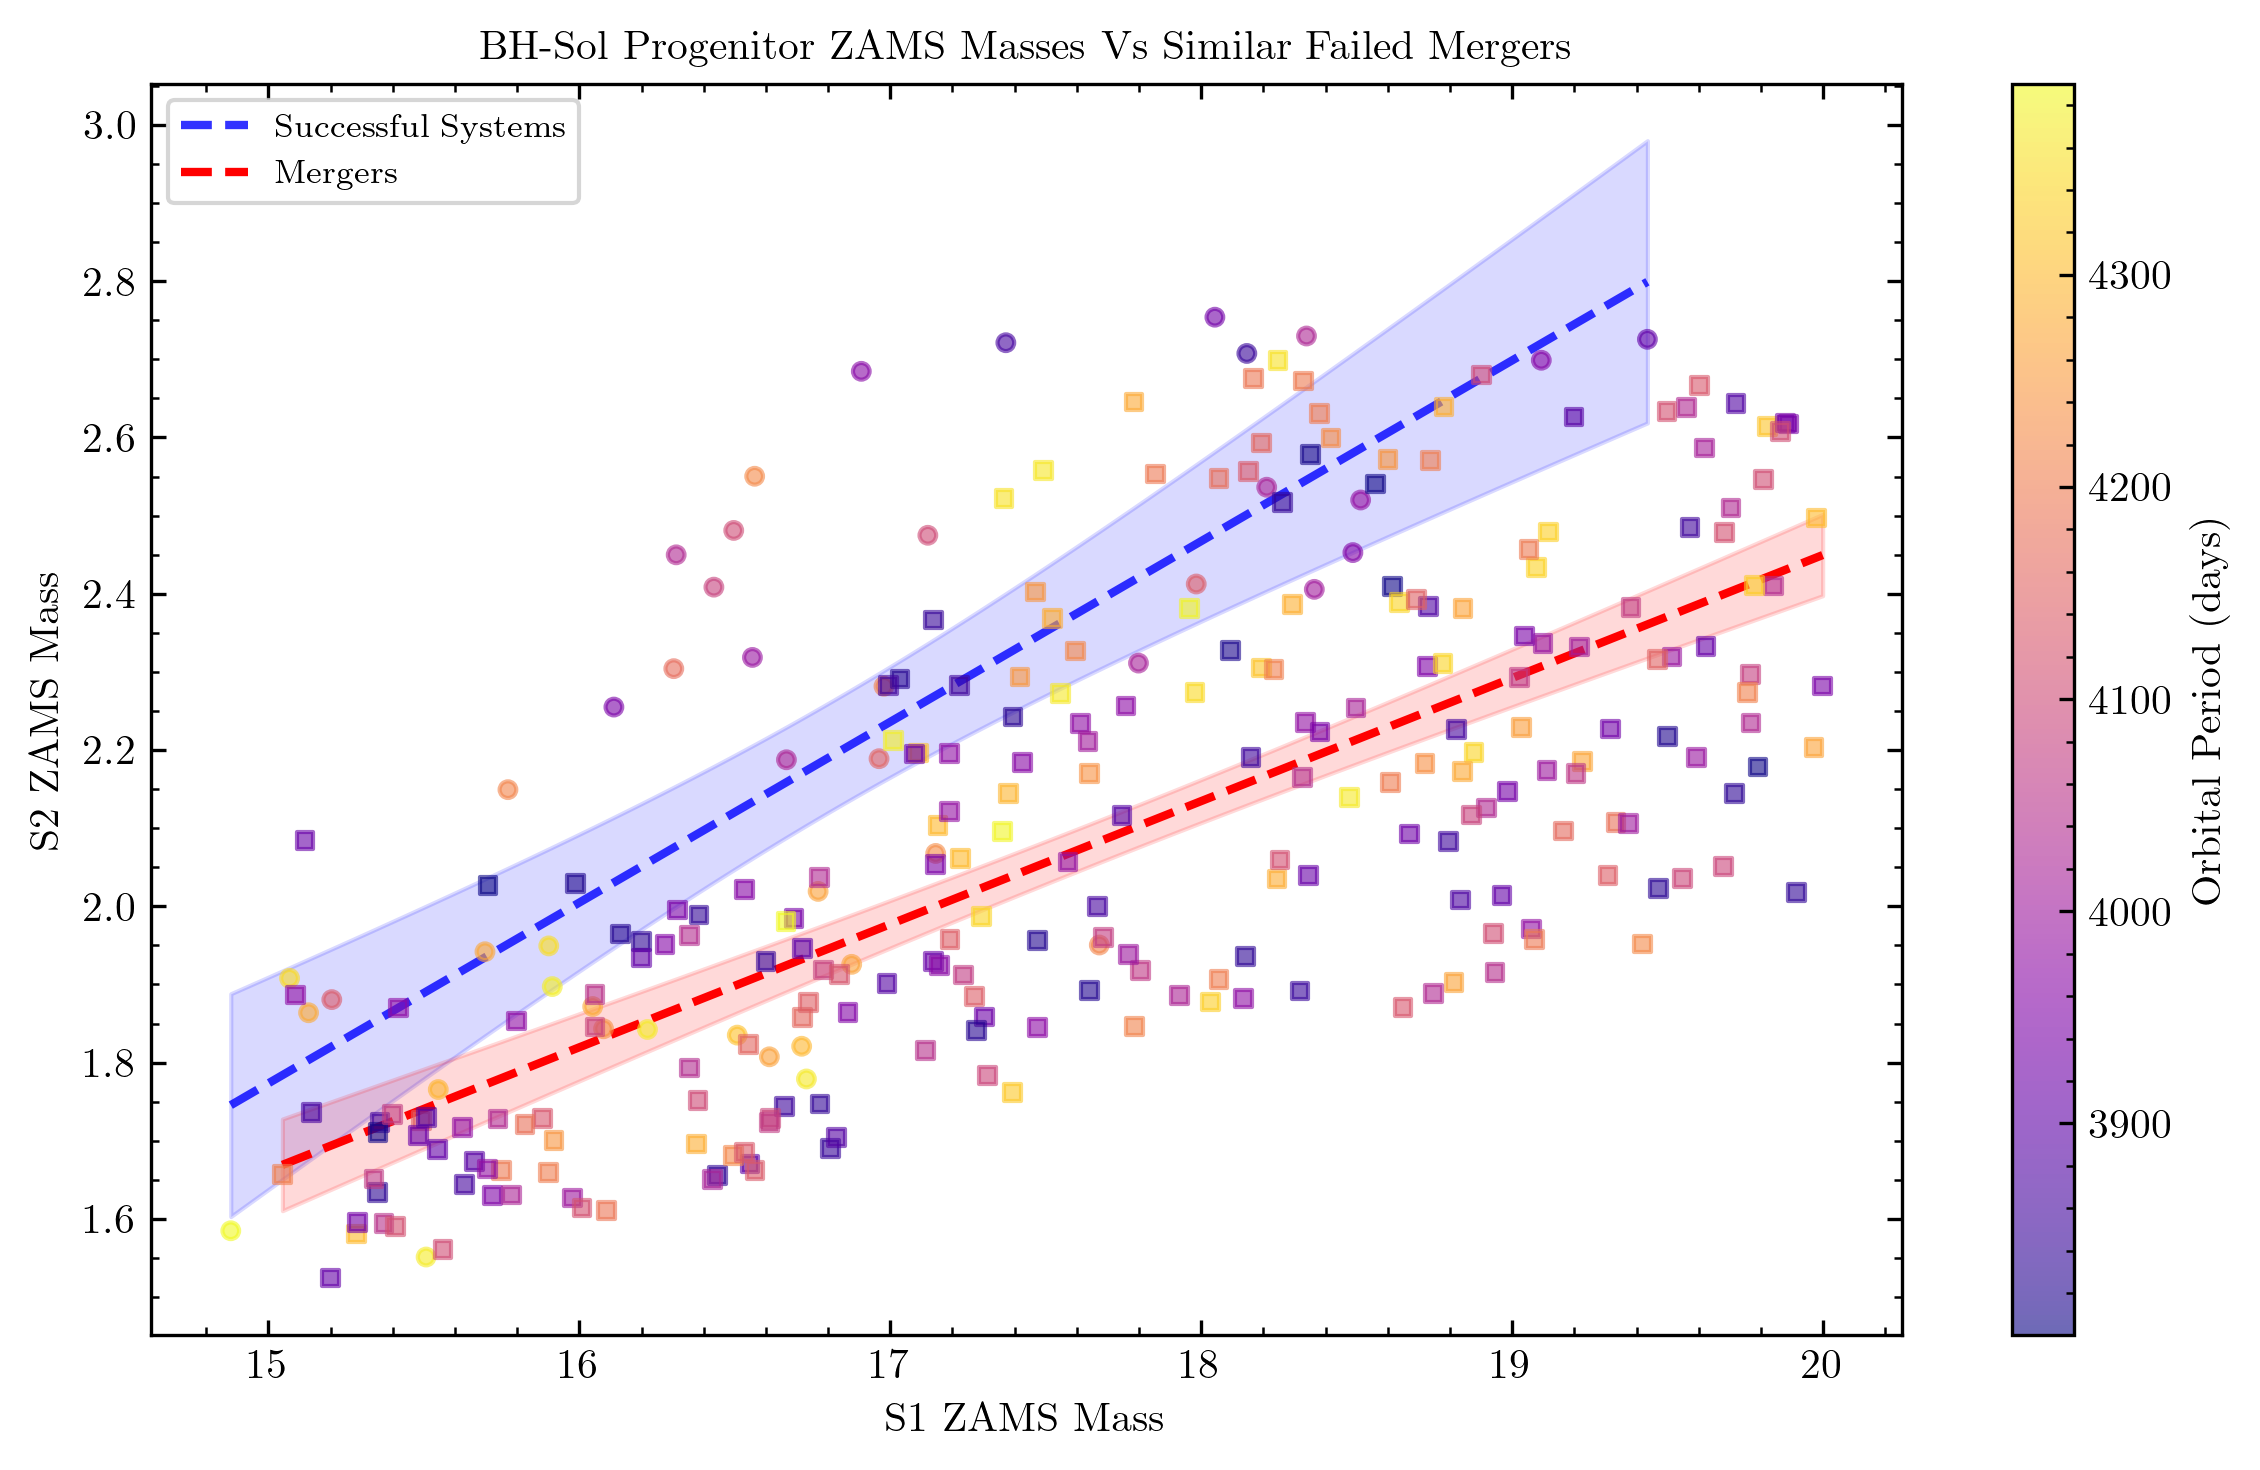

In [54]:
### slop cause regplot cant do colored scatter

from scipy import stats

fig, ax = plt.subplots(figsize=(8, 5))
ci = 95
ci_factor = stats.norm.ppf(0.5 + ci / 200)  # ~1.96 for 95%

x1, y1 = pOneline['S1_mass_i'].values, pOneline['S2_mass_i'].values
x2, y2 = pOneline_merged['S1_mass_i'].values, pOneline_merged['S2_mass_i'].values
c1 = pOneline['orbital_period_i'].values
c2 = pOneline_merged['orbital_period_i'].values

# Shared norm across both datasets
period_min = min(c1.min(), c2.min())
period_max = max(c1.max(), c2.max())
norm = plt.Normalize(period_min, period_max)
cmap = plt.cm.plasma

# --- Dataset 1: scatter + regression ---
ax.scatter(x1, y1, c=c1, cmap=cmap, norm=norm, alpha=0.6, zorder=3)

m1, b1 = np.polyfit(x1, y1, 1)
x1_line = np.linspace(x1.min(), x1.max(), 200)
y1_fit = m1 * x1_line + b1

n1 = len(x1)
y1_pred = m1 * x1 + b1
se1 = np.sqrt(np.sum((y1 - y1_pred) ** 2) / (n1 - 2))
x1_se = se1 * np.sqrt(1/n1 + (x1_line - x1.mean())**2 / np.sum((x1 - x1.mean())**2))
ax.plot(x1_line, y1_fit, color='blue', linestyle='--', linewidth=2, alpha=0.8, label='Successful Systems')
ax.fill_between(x1_line, y1_fit - ci_factor * x1_se, y1_fit + ci_factor * x1_se, alpha=0.15, color='blue')

# --- Dataset 2: scatter + regression ---
sc = ax.scatter(x2, y2, c=c2, cmap=cmap, norm=norm, alpha=0.6, marker='s', zorder=3)

m2, b2 = np.polyfit(x2, y2, 1)
x2_line = np.linspace(x2.min(), x2.max(), 200)
y2_fit = m2 * x2_line + b2

n2 = len(x2)
y2_pred = m2 * x2 + b2
se2 = np.sqrt(np.sum((y2 - y2_pred) ** 2) / (n2 - 2))
x2_se = se2 * np.sqrt(1/n2 + (x2_line - x2.mean())**2 / np.sum((x2 - x2.mean())**2))
ax.plot(x2_line, y2_fit, color='red', linestyle='--', linewidth=2, label='Mergers')
ax.fill_between(x2_line, y2_fit - ci_factor * x2_se, y2_fit + ci_factor * x2_se, alpha=0.15, color='red')

# Colorbar + labels
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Orbital Period (days)')

ax.legend(frameon=True)
ax.set_xlabel('S1 ZAMS Mass')
ax.set_ylabel('S2 ZAMS Mass')
ax.set_title('BH-Sol Progenitor ZAMS Masses Vs Similar Failed Mergers')
plt.tight_layout()
plt.show()

In [55]:
pOneline[initCols]

,orbital_period_i,eccentricity_i,state_i,S2_state_i,S2_mass_i,S2_log_R_i,S1_state_i,S1_mass_i,S1_log_R_i
binary_index,,,,,,,,,
0,4028.254542,0.357737,detached,H-rich_Core_H_burning,2.729828,0.0,H-rich_Core_H_burning,18.338584,0.0
1,3905.179808,0.084004,detached,H-rich_Core_H_burning,2.725585,0.0,H-rich_Core_H_burning,19.435080,0.0
2,4137.423411,0.757557,detached,H-rich_Core_H_burning,2.412479,0.0,H-rich_Core_H_burning,17.983938,0.0
3,4370.857404,0.754004,detached,H-rich_Core_H_burning,1.551266,0.0,H-rich_Core_H_burning,15.506937,0.0
4,3844.570082,0.455501,detached,H-rich_Core_H_burning,2.707498,0.0,H-rich_Core_H_burning,18.146652,0.0
5,4271.287670,0.824328,detached,H-rich_Core_H_burning,1.941911,0.0,H-rich_Core_H_burning,15.696276,0.0
6,4291.679268,0.458543,detached,H-rich_Core_H_burning,1.765590,0.0,H-rich_Core_H_burning,15.546078,0.0
7,4035.130603,0.664716,detached,H-rich_Core_H_burning,2.449812,0.0,H-rich_Core_H_burning,16.311274,0.0
8,3965.440144,0.659758,detached,H-rich_Core_H_burning,2.684643,0.0,H-rich_Core_H_burning,16.906712,0.0
